## Introduction

**CHALLENGE SUMMARY**
* This project aims to develop a supervised machine learning model that classifies customers into credit score brackets using their historical credit and bank data. The main goal is to automate the credit score segmentation process, reducing manual work and ensuring consistent, data-driven assessments. The model's success will be evaluated based on its accuracy and ability to perform well with new customers.

**OUR TEAM’S OBJECTIVE**
* Use this classification further in decisioning process as additional input in ML pipeline

**DESIRED OUTCOMES**
* complete analysis of data, model building steps, serving api, and lesson learned , the objective is to become aware of E2E ML pipeline usage in industry



## Data Understanding & Preprocessing

* Data Understanding: Basic stats of the dataset
* Data cleaning: handling missing values, outliers, duplicates, remove  non alphanumeric characters  
* Data transformation: normalization and label encoding , StandardScaler
* Data Visualization:  Various charts to show the relationship between label and features
Suggested tools and libraries for this stage of the project (e.g., Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn


In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from google.colab import drive

In [10]:
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [11]:

import os


In [13]:
# folder_path = '/content/drive/My Drive/Amex 1B/'
# file_path = os.path.join(folder_path, "train.csv")
# df = pd.read_csv(file_path)

folder_path = '/content/drive/My Drive/Colab Notebooks/'
file_path = os.path.join(folder_path, "train.csv")
df = pd.read_csv(file_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/train.csv'

In [8]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Noticed that some columns should be float64, but are object Dtype. Some values may be incorrect

In [ ]:
df = df.drop(["ID", "Customer_ID", "Month", "Name", "SSN"],axis = 1)

Dropping irrelevant columns from our dataset. May need IDs back later

In [ ]:
df['Age'].unique().tolist()

['23',
 '-500',
 '28_',
 '28',
 '34',
 '54',
 '55',
 '21',
 '31',
 '33',
 '34_',
 '7580',
 '30',
 '30_',
 '24',
 '24_',
 '44',
 '45',
 '40',
 '41',
 '32',
 '33_',
 '35',
 '35_',
 '36',
 '39',
 '37',
 '181',
 '20',
 '46',
 '26',
 '42',
 '19',
 '31_',
 '48',
 '995',
 '40_',
 '37_',
 '38',
 '54_',
 '5079',
 '43',
 '21_',
 '22',
 '6409',
 '16',
 '7080',
 '18',
 '849',
 '3885',
 '20_',
 '15',
 '27',
 '43_',
 '38_',
 '25',
 '3052',
 '14',
 '5342',
 '17',
 '18_',
 '4431',
 '2657',
 '2111_',
 '46_',
 '47',
 '1032',
 '16_',
 '19_',
 '47_',
 '456',
 '5717',
 '53_',
 '53',
 '56',
 '25_',
 '27_',
 '55_',
 '3169',
 '1191',
 '29',
 '42_',
 '7140',
 '48_',
 '49',
 '49_',
 '8233',
 '6955',
 '2534',
 '3115',
 '7657',
 '51',
 '50',
 '5112',
 '50_',
 '32_',
 '6452',
 '2744',
 '22_',
 '17_',
 '1439',
 '29_',
 '5795',
 '4872',
 '1772',
 '15_',
 '1383',
 '5657',
 '52',
 '1934',
 '51_',
 '8352',
 '3734',
 '26_',
 '2056',
 '39_',
 '7508',
 '2339',
 '14_',
 '8406',
 '1424',
 '36_',
 '6953',
 '5626',
 '4471',
 

'Age' column values are treated as strings due to extra '_' being added at the end of our numbers. Also, some of these are negative. What is age? days, years, months, etc.

In [ ]:
df['Annual_Income'].unique().tolist()

['19114.12',
 '34847.84',
 '34847.84_',
 '143162.64',
 '30689.89',
 '30689.89_',
 '35547.71_',
 '35547.71',
 '73928.46',
 '131313.4',
 '10909427.0',
 '34081.38_',
 '34081.38',
 '114838.41',
 '114838.41_',
 '31370.8',
 '33751.27',
 '88640.24',
 '88640.24_',
 '54392.16',
 '54392.16_',
 '8701.545',
 '8701.545_',
 '25546.26',
 '25546.26_',
 '31993.78',
 '92047.08',
 '92047.08_',
 '32284.62',
 '97791.42',
 '97791.42_',
 '19300.34',
 '19514.88',
 '10183.015',
 '10183.015_',
 '106733.13',
 '106733.13_',
 '12600.445',
 '12600.445_',
 '57983.12',
 '57983.12_',
 '20787.69',
 '34290.12',
 '34290.12_',
 '43070.24',
 '43070.24_',
 '28572.39',
 '6515990.0_',
 '39641.54',
 '39641.54_',
 '20186.02',
 '586359.0',
 '18627.64',
 '12986.745',
 '58317.0',
 '42171.98',
 '71681.4',
 '29469.98',
 '29469.98_',
 '72559.36',
 '15566.02',
 '15566.02_',
 '66567.32',
 '12909.895',
 '30788.44',
 '20574.47',
 '20574.47_',
 '148699.32',
 '148699.32_',
 '85554.03',
 '55829.79',
 '18334118.0',
 '19717385.0',
 '14165.23'

Similarly, 'Annual Income' values are strings due to extra '_' being added.

In [ ]:
cols_with_nans = df.isna().sum()[df.isna().sum() > 0].index.tolist()
cols_with_nans

['Monthly_Inhand_Salary',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  object 
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  object 
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [ ]:
number_cols = df.select_dtypes(include = ('number')).columns.tolist()
object_cols = df.select_dtypes(include = ('object')).columns.tolist()
df[object_cols]

,Age,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,11.27,_,809.98,22 Years and 1 Months,No,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,NaN,No,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,-500,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,_,Good,809.98,22 Years and 3 Months,No,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,6.27,Good,809.98,22 Years and 4 Months,No,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,22 Years and 5 Months,No,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",7,11.5,_,502.38,31 Years and 6 Months,No,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",7,11.5,_,502.38,31 Years and 7 Months,No,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",6,11.5,Good,502.38,31 Years and 8 Months,No,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,25,Mechanic,39628.99,2,"Auto Loan, and Student Loan",NaN,11.5,Good,502.38,31 Years and 9 Months,No,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [ ]:

object_cols.remove('Occupation')
object_cols.remove('Type_of_Loan')
object_cols.remove('Credit_Mix')
object_cols.remove('Credit_History_Age')
object_cols.remove('Payment_of_Min_Amount')
object_cols.remove('Payment_Behaviour')
object_cols.remove('Credit_Score')
cols_with_errors = object_cols
cols_with_errors

['Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Monthly_Balance']

The following columns are problematic due to being type object when they should only have numbers: 'Age',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Outstanding_Debt',
 'Payment_of_Min_Amount',
 'Amount_invested_monthly',
 'Monthly_Balance'.

The following columns are problematic due to having null values:'Monthly_Inhand_Salary',
 'Type_of_Loan',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Credit_History_Age',
 'Amount_invested_monthly',
 'Monthly_Balance'



In [ ]:
for col in cols_with_errors:
  print(f"First 100 unique values of {col} column:\n", df[col].unique()[:50])

First 100 unique values of Age column:
 ['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33' '34_' '7580' '30'
 '30_' '24' '24_' '44' '45' '40' '41' '32' '33_' '35' '35_' '36' '39' '37'
 '181' '20' '46' '26' '42' '19' '31_' '48' '995' '40_' '37_' '38' '54_'
 '5079' '43' '21_' '22' '6409' '16' '7080' '18' '849' '3885']
First 100 unique values of Annual_Income column:
 ['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89' '30689.89_'
 '35547.71_' '35547.71' '73928.46' '131313.4' '10909427.0' '34081.38_'
 '34081.38' '114838.41' '114838.41_' '31370.8' '33751.27' '88640.24'
 '88640.24_' '54392.16' '54392.16_' '8701.545' '8701.545_' '25546.26'
 '25546.26_' '31993.78' '92047.08' '92047.08_' '32284.62' '97791.42'
 '97791.42_' '19300.34' '19514.88' '10183.015' '10183.015_' '106733.13'
 '106733.13_' '12600.445' '12600.445_' '57983.12' '57983.12_' '20787.69'
 '34290.12' '34290.12_' '43070.24' '43070.24_' '28572.39' '6515990.0_'
 '39641.54' '39641.54_']
First 100 unique values of Num_of_Loan 

For almost every column, we notice '_' and negative values which are causing our numbers to be strings. For Monthly Balance, we don't see anything weird, so it is probably the NaNs that is causing object type

In [ ]:
invalid_col_indices = {col: df.index[(pd.to_numeric(df[col], errors='coerce').isna()) |(pd.to_numeric(df[col], errors='coerce') < 0)].tolist()for col in cols_with_errors}


Using the pd.to_numeric function, we can find the row index with bad values of all columns in our list.

In [ ]:
df['Age'][invalid_col_indices['Age']]

,Age
2,-500
8,28_
54,34_
58,30_
71,24_
...,...
99933,38_
99937,-500
99942,48_
99963,-500


Lets see if we remove the rows with these indices, if the Age column is treated as an float64 type

In [ ]:
new_df = df.drop(invalid_col_indices['Age'], axis = 0)
new_df['Age'] = new_df['Age'].astype(int)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94175 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       94175 non-null  int64  
 1   Occupation                94175 non-null  object 
 2   Annual_Income             94175 non-null  object 
 3   Monthly_Inhand_Salary     80036 non-null  float64
 4   Num_Bank_Accounts         94175 non-null  int64  
 5   Num_Credit_Card           94175 non-null  int64  
 6   Interest_Rate             94175 non-null  int64  
 7   Num_of_Loan               94175 non-null  object 
 8   Type_of_Loan              83454 non-null  object 
 9   Delay_from_due_date       94175 non-null  int64  
 10  Num_of_Delayed_Payment    87585 non-null  object 
 11  Changed_Credit_Limit      94175 non-null  object 
 12  Num_Credit_Inquiries      92322 non-null  float64
 13  Credit_Mix                94175 non-null  object 
 14  Outstanding

It looks like we caught all of the erroneous indices for the age column. How should we treat negative values and values with an extra '_'?


We can try this for all columns to see if we caught all the bad indices.

In [ ]:
total_invalid_indices = [i for col in cols_with_errors for i in invalid_col_indices[col]]
len(total_invalid_indices)


46513

This is around half our dataset, so we should not remove all these values

In [ ]:
half_df = df.drop(total_invalid_indices, axis = 0)
for col in cols_with_errors:
  half_df[col] = half_df[col].astype(float)
pd.concat([half_df.dtypes.to_frame().T, half_df[:3]], ignore_index=True)


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,float64,object,float64,float64,int64,int64,int64,float64,object,int64,...,object,float64,float64,object,object,float64,float64,object,float64,object
1,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
2,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.45131,Good
3,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172,!@9#%8,340.479212,Good


It looks like all our number types are good. Now, it is time to fix these values

## Task 1 of Milestone 1: Address missing values and outliers




In [ ]:
for col in cols_with_errors:
  for index in invalid_col_indices[col]:
    val = df.at[index,col]
    if isinstance(val,str):
      if col == "age":
          # If value contains '-' or '__-' → replace with 18
          if "-" in val or "__-" in val:
              df.at[index, col] = '18'
      else:
        val = val.rstrip('_')
        val = val.lstrip('-')
        val = val.lstrip('_')
        df.at[index,col] = val

Received information from SG to replace non string values for 'Age' column with 18. Otherwise, getting rid of the negative sign and underscore for bad values

In [ ]:
for col in cols_with_errors:
  print(df[col][invalid_col_indices[col]])

2        500
8         28
54        34
58        30
71        24
        ... 
99933     38
99937    500
99942     48
99963    500
99987     28
Name: Age, Length: 5825, dtype: object
10        34847.84
27        30689.89
32        35547.71
56        34081.38
66       114838.41
           ...    
99959     38321.39
99974     16680.35
99981      37188.1
99993     39628.99
99999     39628.99
Name: Annual_Income, Length: 6980, dtype: object
31       100
34       100
37         0
39       100
53       100
        ... 
99940      0
99958      4
99969    100
99984      5
99987    100
Name: Num_of_Loan, Length: 8661, dtype: object
1        NaN
4        NaN
6          8
10         1
11         3
        ... 
99973    NaN
99974    NaN
99992    NaN
99993    NaN
99998    NaN
Name: Num_of_Delayed_Payment, Length: 10368, dtype: object
2                           
27                      2.01
28                      1.01
29                      3.01
65                          
                ...    

In [ ]:
df[cols_with_errors].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Age                      100000 non-null  object
 1   Annual_Income            100000 non-null  object
 2   Num_of_Loan              100000 non-null  object
 3   Num_of_Delayed_Payment   92998 non-null   object
 4   Changed_Credit_Limit     100000 non-null  object
 5   Outstanding_Debt         100000 non-null  object
 6   Amount_invested_monthly  95521 non-null   object
 7   Monthly_Balance          98800 non-null   object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
df['Num_of_Delayed_Payment'] = pd.to_numeric(df[col], errors = 'coerce')
mean_val = df['Num_of_Delayed_Payment'].mean(skipna=True)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(mean_val)

In [ ]:
df['Amount_invested_monthly'] = pd.to_numeric(df[col], errors = 'coerce')
mean_val = df['Amount_invested_monthly'].mean(skipna=True)
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(mean_val)

In [ ]:
df['Monthly_Balance'] = pd.to_numeric(df[col], errors = 'coerce')
mean_val = df['Monthly_Balance'].mean(skipna=True)
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(mean_val)

In [ ]:
df[cols_with_errors].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  object 
 1   Annual_Income            100000 non-null  object 
 2   Num_of_Loan              100000 non-null  object 
 3   Num_of_Delayed_Payment   100000 non-null  float64
 4   Changed_Credit_Limit     100000 non-null  object 
 5   Outstanding_Debt         100000 non-null  object 
 6   Amount_invested_monthly  100000 non-null  float64
 7   Monthly_Balance          100000 non-null  float64
dtypes: float64(3), object(5)
memory usage: 6.1+ MB


All null values and bad values for our number datatypes should be handled by now.

In [ ]:
for col in cols_with_errors:
  print(f"First 100 unique values of {col} column, now changed:\n", df[col].unique()[:50])

First 100 unique values of Age column, now changed:
 ['23' '500' '28' '34' '54' '55' '21' '31' '33' '7580' '30' '24' '44' '45'
 '40' '41' '32' '35' '36' '39' '37' '181' '20' '46' '26' '42' '19' '48'
 '995' '38' '5079' '43' '22' '6409' '16' '7080' '18' '849' '3885' '15'
 '27' '25' '3052' '14' '5342' '17' '4431' '2657' '2111' '47']
First 100 unique values of Annual_Income column, now changed:
 ['19114.12' '34847.84' '143162.64' '30689.89' '35547.71' '73928.46'
 '131313.4' '10909427.0' '34081.38' '114838.41' '31370.8' '33751.27'
 '88640.24' '54392.16' '8701.545' '25546.26' '31993.78' '92047.08'
 '32284.62' '97791.42' '19300.34' '19514.88' '10183.015' '106733.13'
 '12600.445' '57983.12' '20787.69' '34290.12' '43070.24' '28572.39'
 '6515990.0' '39641.54' '20186.02' '586359.0' '18627.64' '12986.745'
 '58317.0' '42171.98' '71681.4' '29469.98' '72559.36' '15566.02'
 '66567.32' '12909.895' '30788.44' '20574.47' '148699.32' '85554.03'
 '55829.79' '18334118.0']
First 100 unique values of Num_of_L

In [ ]:
df['Changed_Credit_Limit'][df['Changed_Credit_Limit'] == '']

,Changed_Credit_Limit
2,
65,
66,
109,
110,
...,...
99548,
99618,
99800,
99892,


There are empty strings in the Changed Credit Limit that were not detected with isna(). We need to replace these with the mean as well, which we can do after using pd.to_numeric.

In [ ]:
for col in cols_with_errors:
  df[col] = pd.to_numeric(df[col], errors = 'coerce')
df[cols_with_errors].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  int64  
 3   Num_of_Delayed_Payment   100000 non-null  float64
 4   Changed_Credit_Limit     97909 non-null   float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  100000 non-null  float64
 7   Monthly_Balance          100000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


In [ ]:
df['Changed_Credit_Limit'] = pd.to_numeric(df[col], errors = 'coerce')
mean_val = df['Changed_Credit_Limit'].mean(skipna=True)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(mean_val)

In [ ]:
df[cols_with_errors].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  int64  
 3   Num_of_Delayed_Payment   100000 non-null  float64
 4   Changed_Credit_Limit     100000 non-null  float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  100000 non-null  float64
 7   Monthly_Balance          100000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


In [1]:
zscore = {}
for col in cols_with_errors:
  zscores = stats.zscore(df[col]).dropna()
  zscores[col] = zscores.tolist()
print(zscores)

NameError: name 'cols_with_errors' is not defined

## Handling 'object' number types

All number type columns are fixed. The following transformations were done:


1.   -100 -> 100
2.   ___100 -> 100
3. 100___ -> 100
4. na -> mean of column
5. '' -> mean of column



In [ ]:
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  int64  
 3   Num_of_Delayed_Payment   100000 non-null  float64
 4   Changed_Credit_Limit     100000 non-null  float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  100000 non-null  float64
 7   Monthly_Balance          100000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


In [ ]:
df['Occupation'].unique().tolist()

['Scientist',
 '_______',
 'Teacher',
 'Engineer',
 'Entrepreneur',
 'Developer',
 'Lawyer',
 'Media_Manager',
 'Doctor',
 'Journalist',
 'Manager',
 'Accountant',
 'Musician',
 'Mechanic',
 'Writer',
 'Architect']

In [ ]:
df = df.drop(df[df['Occupation'] == '_______'].index,axis = 0)

In [ ]:
df['Occupation'].unique().tolist()

['Scientist',
 'Teacher',
 'Engineer',
 'Entrepreneur',
 'Developer',
 'Lawyer',
 'Media_Manager',
 'Doctor',
 'Journalist',
 'Manager',
 'Accountant',
 'Musician',
 'Mechanic',
 'Writer',
 'Architect']

Dropping the invalid rows with blank occupations.

In [ ]:
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 92938 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      92938 non-null  int64  
 1   Annual_Income            92938 non-null  float64
 2   Num_of_Loan              92938 non-null  int64  
 3   Num_of_Delayed_Payment   92938 non-null  float64
 4   Changed_Credit_Limit     92938 non-null  float64
 5   Outstanding_Debt         92938 non-null  float64
 6   Amount_invested_monthly  92938 non-null  float64
 7   Monthly_Balance          92938 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 6.4 MB


In [ ]:
df['Type_of_Loan'][:100].unique().tolist()

['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
 'Credit-Builder Loan',
 'Auto Loan, Auto Loan, and Not Specified',
 'Not Specified',
 nan,
 'Credit-Builder Loan, and Mortgage Loan',
 'Not Specified, Auto Loan, and Student Loan',
 'Personal Loan, Debt Consolidation Loan, and Auto Loan',
 'Not Specified, and Payday Loan',
 'Credit-Builder Loan, Personal Loan, and Auto Loan',
 'Payday Loan, and Payday Loan',
 'Not Specified, Student Loan, and Personal Loan',
 'Personal Loan, Payday Loan, Student Loan, Auto Loan, Home Equity Loan, Student Loan, and Payday Loan']

Need to one hot encode these, but dropping all nulls for now

In [ ]:
df = df.dropna(subset=['Type_of_Loan'])
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 82395 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      82395 non-null  int64  
 1   Annual_Income            82395 non-null  float64
 2   Num_of_Loan              82395 non-null  int64  
 3   Num_of_Delayed_Payment   82395 non-null  float64
 4   Changed_Credit_Limit     82395 non-null  float64
 5   Outstanding_Debt         82395 non-null  float64
 6   Amount_invested_monthly  82395 non-null  float64
 7   Monthly_Balance          82395 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 5.7 MB


It looks like dropping all the nulls for 'Type_of_Loan' got rid of all the nulls in other columns as well. Only Payment_of_Min_Amount is left

In [ ]:
df['Credit_History_Age'][:20].unique().tolist()

['22 Years and 1 Months',
 nan,
 '22 Years and 3 Months',
 '22 Years and 4 Months',
 '22 Years and 5 Months',
 '22 Years and 6 Months',
 '22 Years and 7 Months',
 '26 Years and 8 Months',
 '26 Years and 9 Months',
 '26 Years and 10 Months',
 '26 Years and 11 Months',
 '27 Years and 0 Months',
 '27 Years and 1 Months',
 '27 Years and 2 Months',
 '17 Years and 10 Months',
 '18 Years and 2 Months',
 '18 Years and 3 Months',
 '18 Years and 4 Months']

In [ ]:
df = df.dropna(subset = ['Credit_History_Age'] )

In [ ]:
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 74908 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      74908 non-null  int64  
 1   Annual_Income            74908 non-null  float64
 2   Num_of_Loan              74908 non-null  int64  
 3   Num_of_Delayed_Payment   74908 non-null  float64
 4   Changed_Credit_Limit     74908 non-null  float64
 5   Outstanding_Debt         74908 non-null  float64
 6   Amount_invested_monthly  74908 non-null  float64
 7   Monthly_Balance          74908 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 5.1 MB


All null values have been removed, now we can just fix erroneous values

In [ ]:
df['Credit_Mix'][:100].unique().tolist()

['_', 'Good', 'Standard']

In [ ]:
df['Credit_Score'][:100].unique().tolist()

['Good', 'Standard', 'Poor']

Based on the Credit Score column, I would assume the '_' is Poor, so I will do that.

In [ ]:
df.loc[df['Credit_Mix'] == '_', 'Credit_Mix'] = 'Poor'
df['Credit_Mix'][:100].unique().tolist()

['Poor', 'Good', 'Standard']

In [ ]:
df['Payment_of_Min_Amount'].unique().tolist()

['No', 'NM', 'Yes']

Nothing looks incorrect here

In [ ]:
df['Payment_Behaviour'].unique().tolist()

['High_spent_Small_value_payments',
 'Low_spent_Medium_value_payments',
 'Low_spent_Small_value_payments',
 'High_spent_Medium_value_payments',
 '!@9#%8',
 'High_spent_Large_value_payments',
 'Low_spent_Large_value_payments']

In [ ]:
df = df.drop(df[df['Payment_Behaviour'] == '!@9#%8'].index,axis = 0)
df['Payment_Behaviour'].unique().tolist()

['High_spent_Small_value_payments',
 'Low_spent_Medium_value_payments',
 'Low_spent_Small_value_payments',
 'High_spent_Medium_value_payments',
 'High_spent_Large_value_payments',
 'Low_spent_Large_value_payments']

In [ ]:
df[object_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      69233 non-null  int64  
 1   Annual_Income            69233 non-null  float64
 2   Num_of_Loan              69233 non-null  int64  
 3   Num_of_Delayed_Payment   69233 non-null  float64
 4   Changed_Credit_Limit     69233 non-null  float64
 5   Outstanding_Debt         69233 non-null  float64
 6   Amount_invested_monthly  69233 non-null  float64
 7   Monthly_Balance          69233 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 4.8 MB


## Handling Object types

The following changes were made to columns with object types:


1.   Occupation: '_______'  -> dropped
2.   Type of Loan: na -> dropped
3.   Credit mix: '_' -> Poor
4.   Payment Behaviour: !@9#%8 -> dropped



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       69233 non-null  int64  
 1   Occupation                69233 non-null  object 
 2   Annual_Income             69233 non-null  float64
 3   Monthly_Inhand_Salary     58886 non-null  float64
 4   Num_Bank_Accounts         69233 non-null  int64  
 5   Num_Credit_Card           69233 non-null  int64  
 6   Interest_Rate             69233 non-null  int64  
 7   Num_of_Loan               69233 non-null  int64  
 8   Type_of_Loan              69233 non-null  object 
 9   Delay_from_due_date       69233 non-null  int64  
 10  Num_of_Delayed_Payment    69233 non-null  float64
 11  Changed_Credit_Limit      69233 non-null  float64
 12  Num_Credit_Inquiries      67873 non-null  float64
 13  Credit_Mix                69233 non-null  object 
 14  Outstanding

It seems that in the number columns that were correctly listed as their number types, there are still null values. Hopefully, it is possible to just do mean replacement

In [ ]:
df.isna().sum()

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,10347
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,0
Delay_from_due_date,0


In [ ]:
df[number_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Monthly_Inhand_Salary     58886 non-null  float64
 1   Num_Bank_Accounts         69233 non-null  int64  
 2   Num_Credit_Card           69233 non-null  int64  
 3   Interest_Rate             69233 non-null  int64  
 4   Delay_from_due_date       69233 non-null  int64  
 5   Num_Credit_Inquiries      67873 non-null  float64
 6   Credit_Utilization_Ratio  69233 non-null  float64
 7   Total_EMI_per_month       69233 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 4.8 MB


These are the original number columns in the array

In [ ]:
mean_val = df['Monthly_Inhand_Salary'].mean(skipna = True)
df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].fillna(value = mean_val)
df[number_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Monthly_Inhand_Salary     69233 non-null  float64
 1   Num_Bank_Accounts         69233 non-null  int64  
 2   Num_Credit_Card           69233 non-null  int64  
 3   Interest_Rate             69233 non-null  int64  
 4   Delay_from_due_date       69233 non-null  int64  
 5   Num_Credit_Inquiries      67873 non-null  float64
 6   Credit_Utilization_Ratio  69233 non-null  float64
 7   Total_EMI_per_month       69233 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 4.8 MB


In [ ]:
mean_val = df['Num_Credit_Inquiries'].mean(skipna = True)
df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].fillna(value = mean_val)
df[number_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Monthly_Inhand_Salary     69233 non-null  float64
 1   Num_Bank_Accounts         69233 non-null  int64  
 2   Num_Credit_Card           69233 non-null  int64  
 3   Interest_Rate             69233 non-null  int64  
 4   Delay_from_due_date       69233 non-null  int64  
 5   Num_Credit_Inquiries      69233 non-null  float64
 6   Credit_Utilization_Ratio  69233 non-null  float64
 7   Total_EMI_per_month       69233 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 4.8 MB


Did mean replacement for original number columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       69233 non-null  int64  
 1   Occupation                69233 non-null  object 
 2   Annual_Income             69233 non-null  float64
 3   Monthly_Inhand_Salary     69233 non-null  float64
 4   Num_Bank_Accounts         69233 non-null  int64  
 5   Num_Credit_Card           69233 non-null  int64  
 6   Interest_Rate             69233 non-null  int64  
 7   Num_of_Loan               69233 non-null  int64  
 8   Type_of_Loan              69233 non-null  object 
 9   Delay_from_due_date       69233 non-null  int64  
 10  Num_of_Delayed_Payment    69233 non-null  float64
 11  Changed_Credit_Limit      69233 non-null  float64
 12  Num_Credit_Inquiries      69233 non-null  float64
 13  Credit_Mix                69233 non-null  object 
 14  Outstanding

In [ ]:
df.isna().sum()

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,0
Delay_from_due_date,0


## Task 2 of Milestone 1: Standardize categorical variables, normalize numerical features

In [ ]:
df['Credit_History_Age'][:50].unique().tolist()
#should this be converted to a quantitative var?

['22 Years and 1 Months',
 '22 Years and 3 Months',
 '22 Years and 4 Months',
 '22 Years and 5 Months',
 '22 Years and 7 Months',
 '26 Years and 8 Months',
 '26 Years and 9 Months',
 '26 Years and 10 Months',
 '26 Years and 11 Months',
 '27 Years and 0 Months',
 '27 Years and 1 Months',
 '27 Years and 2 Months',
 '17 Years and 10 Months',
 '18 Years and 2 Months',
 '18 Years and 3 Months',
 '18 Years and 4 Months',
 '17 Years and 3 Months',
 '17 Years and 4 Months',
 '17 Years and 5 Months',
 '17 Years and 6 Months',
 '17 Years and 7 Months',
 '17 Years and 9 Months',
 '30 Years and 7 Months',
 '30 Years and 8 Months',
 '30 Years and 9 Months',
 '30 Years and 10 Months',
 '30 Years and 11 Months',
 '31 Years and 0 Months',
 '31 Years and 2 Months',
 '14 Years and 8 Months',
 '14 Years and 9 Months',
 '15 Years and 1 Months',
 '15 Years and 2 Months',
 '21 Years and 4 Months',
 '21 Years and 5 Months',
 '21 Years and 6 Months',
 '21 Years and 8 Months',
 '21 Years and 10 Months',
 '21 Y

In [ ]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Poor,809.98,26.822620,22 Years and 1 Months,No,49.574949,312.494089,High_spent_Small_value_payments,312.494089,Good
2,500,Scientist,19114.12,4068.547364,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,331.209863,Low_spent_Medium_value_payments,331.209863,Good
3,23,Scientist,19114.12,4068.547364,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,223.451310,Low_spent_Small_value_payments,223.451310,Good
4,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,341.489231,High_spent_Medium_value_payments,341.489231,Good
6,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,244.565317,Low_spent_Small_value_payments,244.565317,Good


In [ ]:
#Switched from string to float. I'm not sure why it's being saved as float instead of an int. I can't do the fill na method with floats, but once I figure out how to get this to int, I can implement it
df['Credit_History_Age'].unique().tolist()
def convert_to_months(val):
    if pd.isna(val):
        return np.nan
    parts = val.split()
    years = int(parts[0])
    months = int(parts[3])
    return int(years * 12 + months)
df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months)
df['Credit_History_Age'][:50].unique().tolist()


[265,
 267,
 268,
 269,
 271,
 320,
 321,
 322,
 323,
 324,
 325,
 326,
 214,
 218,
 219,
 220,
 207,
 208,
 209,
 210,
 211,
 213,
 367,
 368,
 369,
 370,
 371,
 372,
 374,
 176,
 177,
 181,
 182,
 256,
 257,
 258,
 260,
 262,
 263,
 318,
 319,
 230,
 231,
 233,
 234]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       69233 non-null  int64  
 1   Occupation                69233 non-null  object 
 2   Annual_Income             69233 non-null  float64
 3   Monthly_Inhand_Salary     69233 non-null  float64
 4   Num_Bank_Accounts         69233 non-null  int64  
 5   Num_Credit_Card           69233 non-null  int64  
 6   Interest_Rate             69233 non-null  int64  
 7   Num_of_Loan               69233 non-null  int64  
 8   Type_of_Loan              69233 non-null  object 
 9   Delay_from_due_date       69233 non-null  int64  
 10  Num_of_Delayed_Payment    69233 non-null  float64
 11  Changed_Credit_Limit      69233 non-null  float64
 12  Num_Credit_Inquiries      69233 non-null  float64
 13  Credit_Mix                69233 non-null  object 
 14  Outstanding

In [ ]:
# Task 2 : ordinal encoding catagorical featuers
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
# replace "-" with NaN in both columns
df['Credit_Score'] = df['Credit_Score'].replace("-", np.nan)
df['Credit_Mix']   = df['Credit_Mix'].replace("-", np.nan)

# make a copy to compare before/after
df_compare = df[['Credit_Score', 'Credit_Mix']].copy()

# Encode Credit_Score (Poor < Standard < Good)
ord_enc_score = OrdinalEncoder(categories=[['Poor', 'Standard', 'Good']])
df_compare['Credit_Score_Encoded'] = ord_enc_score.fit_transform(df_compare[['Credit_Score']])

# Encode Credit_Mix (Bad < Poor < Standard < Good)
ord_enc_mix = OrdinalEncoder(categories=[['Bad', 'Poor', 'Standard', 'Good']])
df_compare['Credit_Mix_Encoded'] = ord_enc_mix.fit_transform(df_compare[['Credit_Mix']])

# Show first 10 rows before & after
print(" BEFORE & AFTER ENCODING (first 10 rows)")
print(df_compare.head(10))

#  Check unique values (sorted for clarity)
print("\nUnique values in 'Credit_Score_Encoded':", np.sort(df_compare['Credit_Score_Encoded'].unique()))
print("Unique values in 'Credit_Mix_Encoded':", np.sort(df_compare['Credit_Mix_Encoded'].unique()))




 BEFORE & AFTER ENCODING (first 10 rows)
   Credit_Score Credit_Mix  Credit_Score_Encoded  Credit_Mix_Encoded
0          Good       Poor                   2.0                 1.0
2          Good       Good                   2.0                 3.0
3          Good       Good                   2.0                 3.0
4          Good       Good                   2.0                 3.0
6          Good       Good                   2.0                 3.0
9          Good       Good                   2.0                 3.0
10     Standard       Poor                   1.0                 1.0
11         Good       Good                   2.0                 3.0
12         Good       Good                   2.0                 3.0
13         Good       Good                   2.0                 3.0

Unique values in 'Credit_Score_Encoded': [0. 1. 2.]
Unique values in 'Credit_Mix_Encoded': [0. 1. 2. 3.]


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Poor,809.98,26.822620,265,No,49.574949,312.494089,High_spent_Small_value_payments,312.494089,Good
2,500,Scientist,19114.12,4068.547364,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,267,No,49.574949,331.209863,Low_spent_Medium_value_payments,331.209863,Good
3,23,Scientist,19114.12,4068.547364,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,268,No,49.574949,223.451310,Low_spent_Small_value_payments,223.451310,Good
4,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,269,No,49.574949,341.489231,High_spent_Medium_value_payments,341.489231,Good
6,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,22.537593,271,No,49.574949,244.565317,Low_spent_Small_value_payments,244.565317,Good


In [ ]:
df['Credit_Score'] = df_compare['Credit_Score_Encoded']
df['Credit_Mix'] = df_compare['Credit_Mix_Encoded']
df.head()
print(df['Credit_Score'].unique().tolist())
print(df['Credit_Mix'].unique().tolist())

[2.0, 1.0, 0.0]
[1.0, 3.0, 2.0, 0.0]


In [ ]:

# checking the unique values of these catagorical columns before useing one hot encoding
categorical_columns = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour', 'Payment_of_Min_Amount']

for col in categorical_columns:
    print(f"Unique values in '{col}' column:", df[col].unique())
    print(f"Data type of '{col}' column:", df[col].dtype)


Unique values in 'Occupation' column: ['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Lawyer' 'Media_Manager'
 'Doctor' 'Journalist' 'Manager' 'Mechanic' 'Writer' 'Accountant'
 'Architect' 'Musician' 'Developer']
Data type of 'Occupation' column: object
Unique values in 'Type_of_Loan' column: ['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified' ...
 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan'
 'Payday Loan, Student Loan, Mortgage Loan, and Not Specified'
 'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan']
Data type of 'Type_of_Loan' column: object
Unique values in 'Payment_Behaviour' column: ['High_spent_Small_value_payments' 'Low_spent_Medium_value_payments'
 'Low_spent_Small_value_payments' 'High_spent_Medium_value_payments'
 'High_spent_Large_value_payments' 'Low_spent_Large_value_payments']
Data type of 'Payment_Behaviour' column: object
Unique values in 'Payment

In [ ]:
df['Type_of_Loan'][:100].unique().tolist()

['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
 'Credit-Builder Loan',
 'Auto Loan, Auto Loan, and Not Specified',
 'Not Specified',
 'Credit-Builder Loan, and Mortgage Loan',
 'Not Specified, Auto Loan, and Student Loan',
 'Personal Loan, Debt Consolidation Loan, and Auto Loan',
 'Not Specified, and Payday Loan',
 'Credit-Builder Loan, Personal Loan, and Auto Loan',
 'Payday Loan, and Payday Loan',
 'Not Specified, Student Loan, and Personal Loan',
 'Personal Loan, Payday Loan, Student Loan, Auto Loan, Home Equity Loan, Student Loan, and Payday Loan',
 'Not Specified, Student Loan, Student Loan, Credit-Builder Loan, and Auto Loan',
 'Payday Loan, and Home Equity Loan',
 'Credit-Builder Loan, Not Specified, Mortgage Loan, Payday Loan, Credit-Builder Loan, and Personal Loan',
 'Mortgage Loan, Debt Consolidation Loan, Payday Loan, Auto Loan, and Not Specified']

In [ ]:
all_loans = set()
for val in df['Type_of_Loan']:
  for loan in val.split(","):
    loan = loan.replace("and", "").strip()
    if (loan):
      all_loans.add(loan)
print(all_loans)

{'Personal Loan', 'Credit-Builder Loan', 'Not Specified', 'Debt Consolidation Loan', 'Mortgage Loan', 'Payday Loan', 'Student Loan', 'Auto Loan', 'Home Equity Loan'}


In [ ]:
loan_encoded = pd.DataFrame({
    loan: df["Type_of_Loan"].str.count(loan)
    for loan in all_loans
})
print(loan_encoded.head(1))
print(df['Type_of_Loan'][0])

   Personal Loan  Credit-Builder Loan  Not Specified  Debt Consolidation Loan  \
0              1                    1              0                        0   

   Mortgage Loan  Payday Loan  Student Loan  Auto Loan  Home Equity Loan  
0              0            0             0          1                 1  
Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan


Hopefully, this captures every type of loan found in each column

In [ ]:
print(df.shape, len(all_loans))
df = pd.concat([df, loan_encoded], axis = 1)
print(df.shape)

(69233, 23) 9
(69233, 32)


In [ ]:

# # get all unique loan types
# df['Type_of_Loan_List'] = df['Type_of_Loan'].apply(lambda x: [i.strip() for i in x.split(',')])
# all_loans = set([loan for sublist in df['Type_of_Loan_List'] for loan in sublist])

# # create binary columns for each loan type
# for loan in all_loans:
#   df[loan] = df['Type_of_Loan_List'].apply(lambda x: 1 if loan in x else 0)

# one hot encode Occupation and payment behavior
df_encoded = pd.get_dummies(df[['Occupation', 'Payment_Behaviour', 'Payment_of_Min_Amount']])

# drop original catagorical columns
df = df.drop(columns=['Occupation', 'Payment_Behaviour', 'Type_of_Loan',  'Payment_of_Min_Amount'])
# can change true false values to 0,1 if needed with this line of code
# One-hot encode 'Occupation' and 'Payment_Behaviour' as integers
#df_encoded = pd.get_dummies(df[['Occupation', 'Payment_Behaviour']].astype(str), drop_first=True).astype(int)
# combine the one hot encoded columns
df = pd.concat([df, df_encoded], axis=1)


print(df.columns)
# printing unique values for each column changed
changed_cols = list(all_loans) + list(df_encoded.columns)

print("\nAfter One-Hot Encoding :")
for col in changed_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Data type:", df[col].dtype)

print("\nShape of dataframe after encoding:", df.shape)


Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score',
       'Personal Loan', 'Credit-Builder Loan', 'Not Specified',
       'Debt Consolidation Loan', 'Mortgage Loan', 'Payday Loan',
       'Student Loan', 'Auto Loan', 'Home Equity Loan',
       'Occupation_Accountant', 'Occupation_Architect', 'Occupation_Developer',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation

In [ ]:
# normalize numerical features
numeric_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary',
                    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                    'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
                    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
                    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
                    'Amount_invested_monthly', 'Monthly_Balance']

scaler = StandardScaler()
# calculates the mean and standard deviation of each column & subtracts the mean and divides by the std to standardize the data
# mean = 0, std = 1
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,69233.000000,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04,6.923300e+04
mean,-2.257874e-18,2.771027e-18,1.354724e-16,-3.181550e-18,6.978884e-18,1.077622e-17,0.000000,6.691518e-17,5.747316e-18,5.747316e-18,-2.214256e-17,6.978884e-18,9.773516e-16,-3.684440e-17,3.694703e-18,5.747316e-18,5.747316e-18
std,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00
min,-1.529939e-01,-1.165177e-01,-1.306712e+00,-1.547770e-01,-1.749569e-01,-1.559030e-01,-0.165675,-1.768282e+00,-9.944555e+01,-9.944555e+01,-1.467511e-01,-1.268235e+00,-2.379829e+00,-2.120992e+00,-1.688757e-01,-9.944555e+01,-9.944555e+01
25%,-1.382957e-01,-1.081877e-01,-8.149744e-01,-1.120107e-01,-1.437021e-01,-1.411307e-01,-0.149314,-7.866316e-01,1.017471e-02,1.017471e-02,-1.309154e-01,-7.603319e-01,-8.274650e-01,-7.894523e-01,-1.643460e-01,1.017471e-02,1.017471e-02
50%,-1.250673e-01,-9.591429e-02,-1.223930e-01,-9.490423e-02,-1.280747e-01,-1.263583e-01,-0.116592,-1.976412e-01,1.017471e-02,1.017471e-02,-1.150798e-01,-2.257041e-01,3.574159e-03,-1.856103e-02,-1.597092e-01,1.017471e-02,1.017471e-02
75%,-1.118389e-01,-7.202245e-02,3.920467e-01,-7.779773e-02,-1.202610e-01,-1.115860e-01,-0.083870,4.567926e-01,1.017471e-02,1.017471e-02,-9.924423e-02,5.277383e-01,8.276546e-01,7.823650e-01,-1.483335e-01,1.017471e-02,1.017471e-02
max,1.258741e+01,1.676202e+01,3.865082e+00,1.523252e+01,1.153779e+01,1.207558e+01,24.097689,2.943641e+00,1.017471e-02,1.017471e-02,1.354577e+01,2.927917e+00,3.427860e+00,1.913673e+00,9.876620e+00,1.017471e-02,1.017471e-02


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 52 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 69233 non-null  float64
 1   Annual_Income                                       69233 non-null  float64
 2   Monthly_Inhand_Salary                               69233 non-null  float64
 3   Num_Bank_Accounts                                   69233 non-null  float64
 4   Num_Credit_Card                                     69233 non-null  float64
 5   Interest_Rate                                       69233 non-null  float64
 6   Num_of_Loan                                         69233 non-null  float64
 7   Delay_from_due_date                                 69233 non-null  float64
 8   Num_of_Delayed_Payment                              69233 non-null  float64
 9   

In [ ]:
df = df.drop(columns = 'Not Specified')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69233 entries, 0 to 99998
Data columns (total 51 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 69233 non-null  float64
 1   Annual_Income                                       69233 non-null  float64
 2   Monthly_Inhand_Salary                               69233 non-null  float64
 3   Num_Bank_Accounts                                   69233 non-null  float64
 4   Num_Credit_Card                                     69233 non-null  float64
 5   Interest_Rate                                       69233 non-null  float64
 6   Num_of_Loan                                         69233 non-null  float64
 7   Delay_from_due_date                                 69233 non-null  float64
 8   Num_of_Delayed_Payment                              69233 non-null  float64
 9   

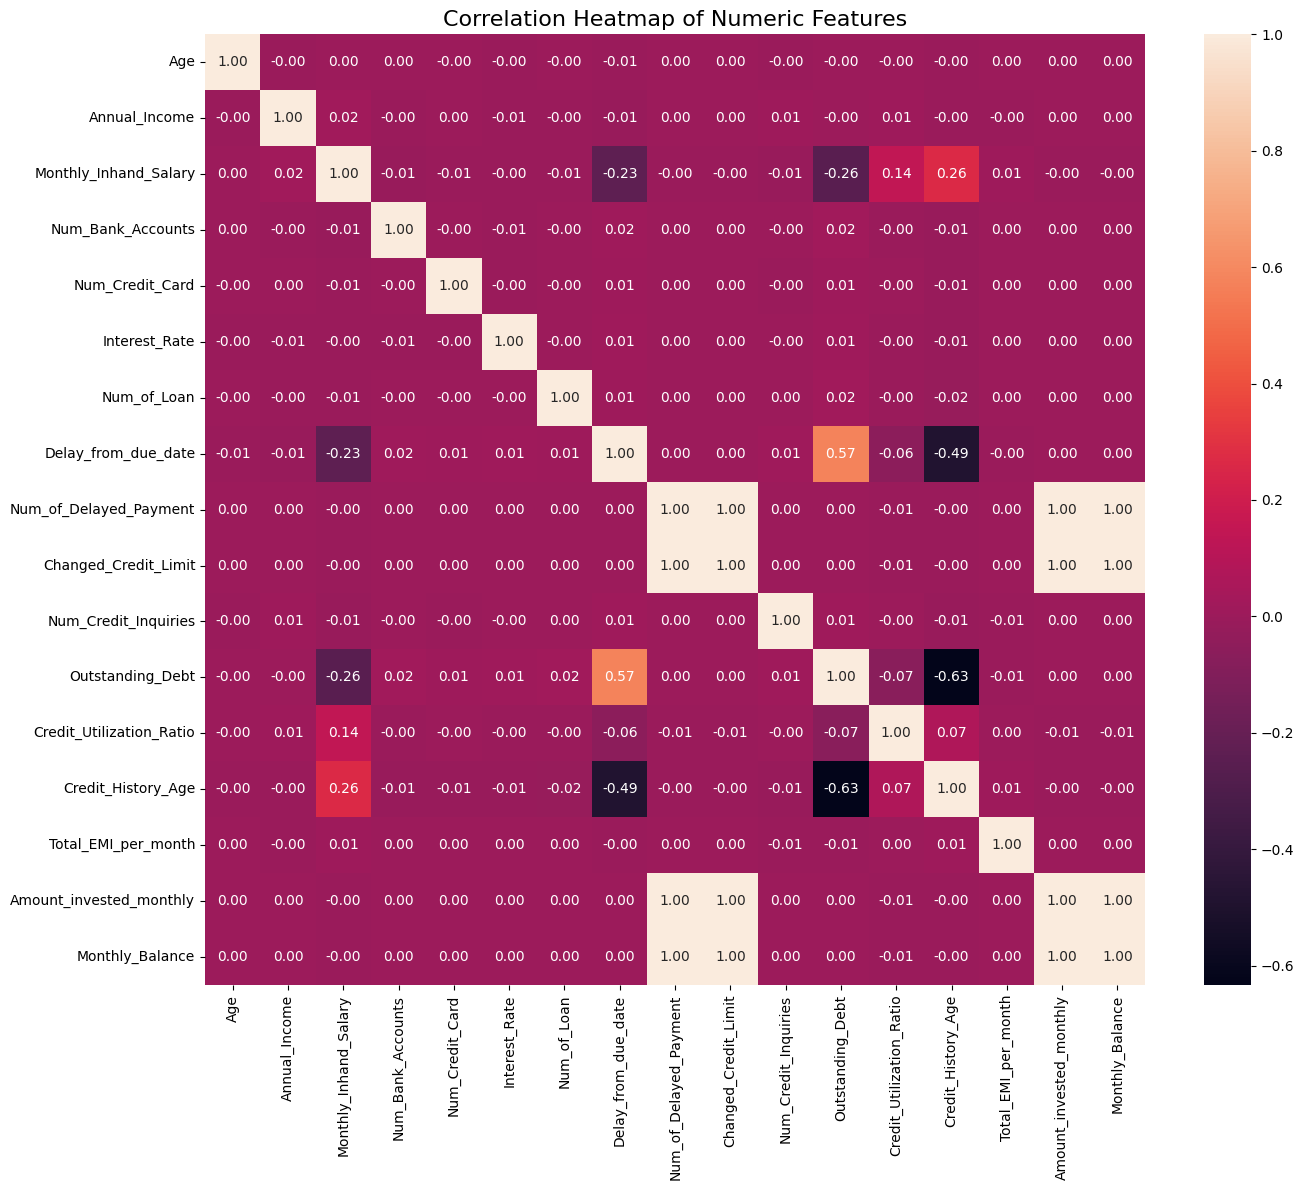

In [ ]:
import seaborn as sns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df = numeric_df.drop(columns = ['Credit_Mix', 'Credit_Score', 'Student Loan', 'Credit-Builder Loan' , 'Personal Loan', 'Mortgage Loan', 'Debt Consolidation Loan' ,'Home Equity Loan' ,'Auto Loan','Payday Loan'])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size":10}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


I don't know why, but some columns that aren't diagonals have a correlation of 1. I won't include these, but I will consider $|r| \geq .15$ as a strong correlation.

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)

strong_corr = corr_pairs[(abs(corr_pairs['Correlation']) > 0.15) & (corr_pairs['Correlation'] != 1)]

strong_corr = strong_corr.sort_values(by='Correlation', key=abs, ascending=False)

print(strong_corr)
print(len(strong_corr))


                 Feature_1            Feature_2  Correlation
122       Outstanding_Debt   Credit_History_Age    -0.633214
94     Delay_from_due_date     Outstanding_Debt     0.572649
96     Delay_from_due_date   Credit_History_Age    -0.490041
41   Monthly_Inhand_Salary   Credit_History_Age     0.261243
39   Monthly_Inhand_Salary     Outstanding_Debt    -0.256388
35   Monthly_Inhand_Salary  Delay_from_due_date    -0.232119
6


6 unique pairwise columns have correlation greater than .15. Let's visualize these

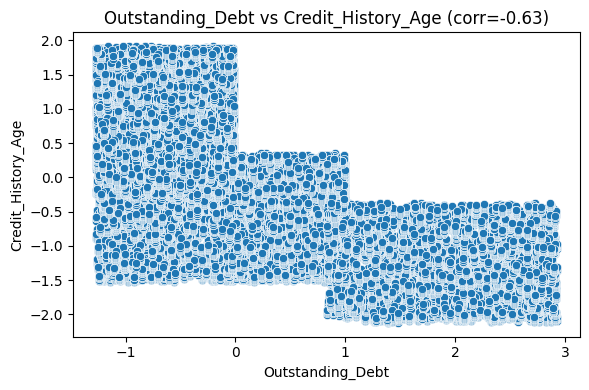

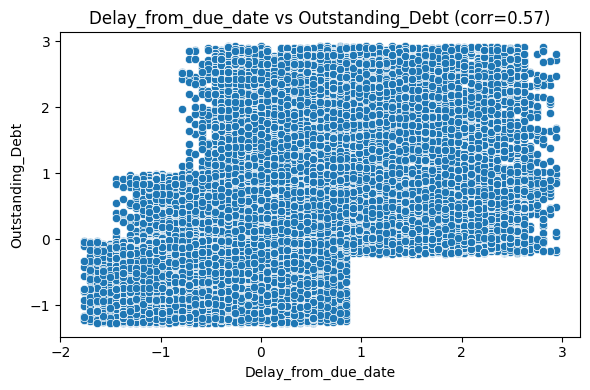

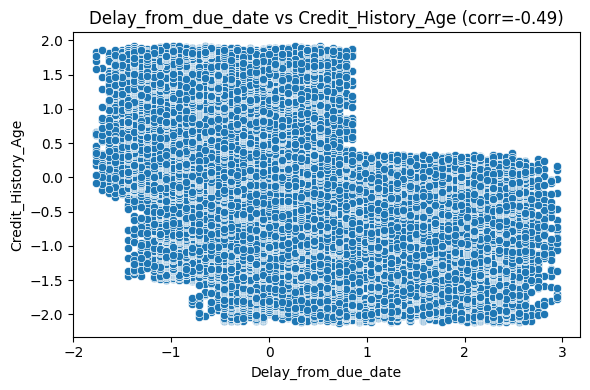

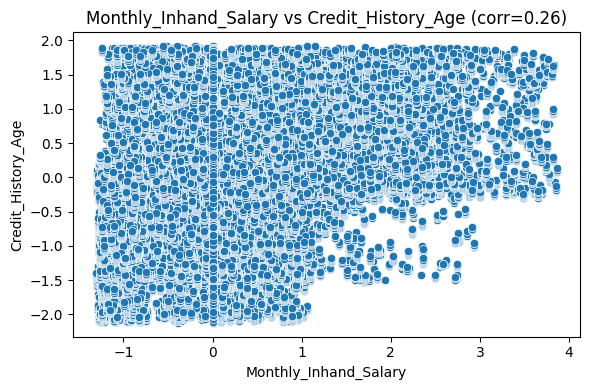

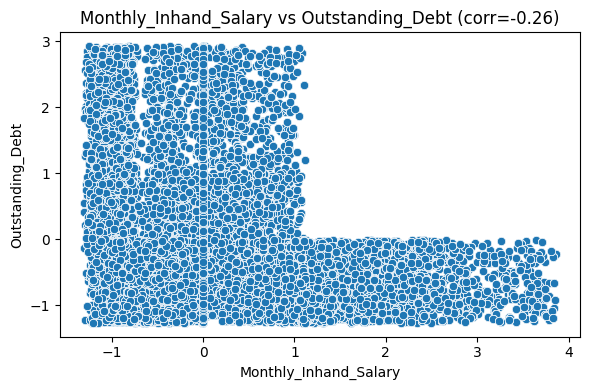

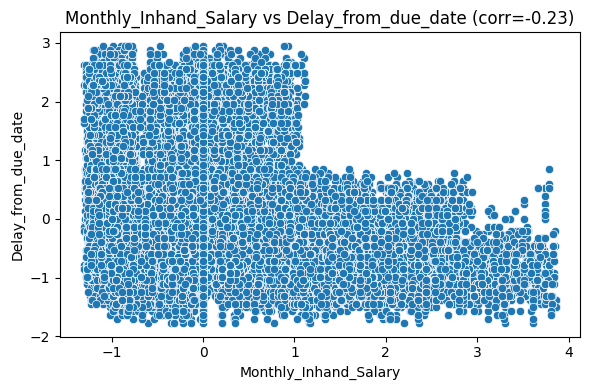

In [ ]:
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=numeric_df[feature_x], y=numeric_df[feature_y])
    plt.title(f"{feature_x} vs {feature_y} (corr={corr_val:.2f})")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()


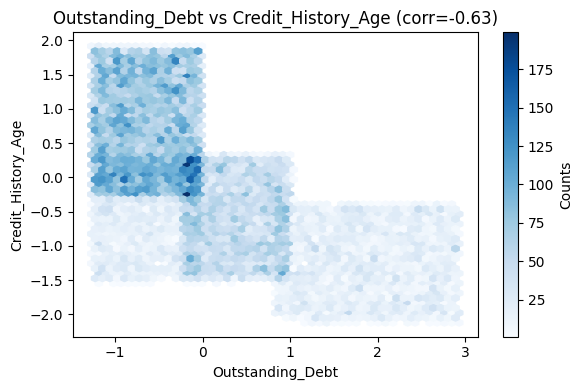

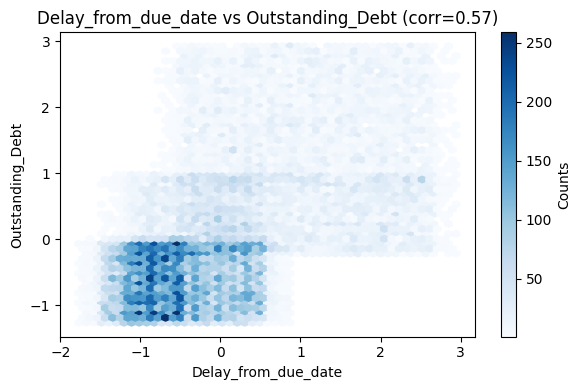

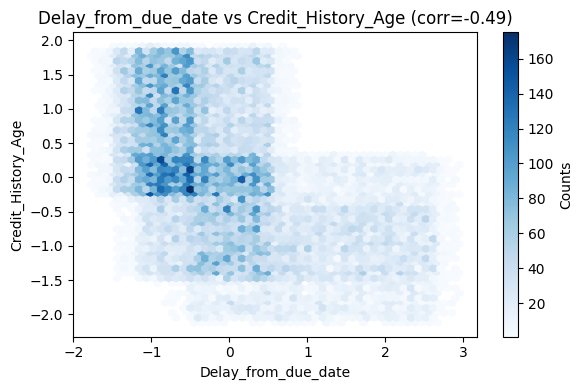

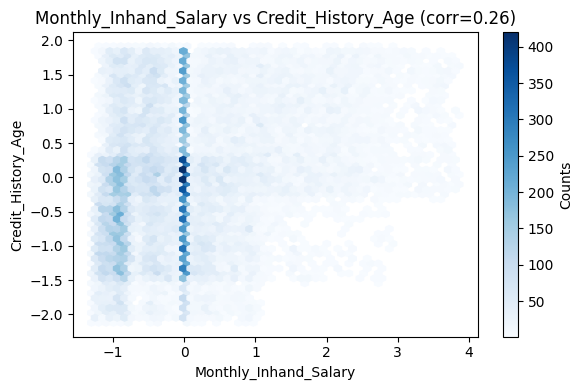

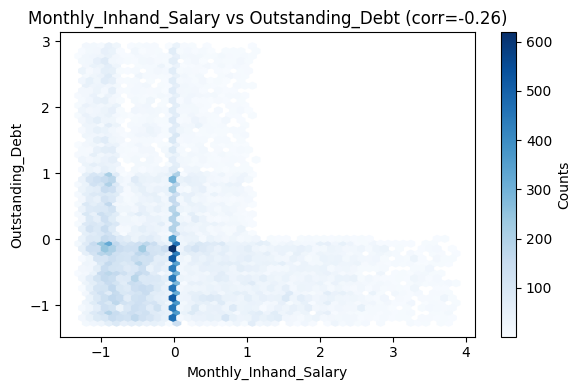

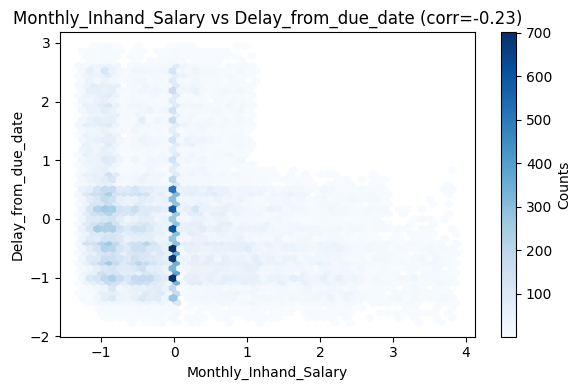

In [ ]:
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    plt.figure(figsize=(6, 4))
    plt.hexbin(
        numeric_df[feature_x],
        numeric_df[feature_y],
        gridsize=50,
        cmap='Blues',
        mincnt=1
    )
    plt.colorbar(label='Counts')
    plt.title(f"{feature_x} vs {feature_y} (corr={corr_val:.2f})")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.tight_layout()
    plt.show()


In [ ]:
numeric_df_new = numeric_df.copy()
for _, row in strong_corr.iterrows():
    feature_x = row['Feature_1']
    feature_y = row['Feature_2']
    corr_val = row['Correlation']

    new_col_name = f"{feature_x}_x_{feature_y}"
    numeric_df_new[new_col_name] = numeric_df_new[feature_x] * numeric_df_new[feature_y]



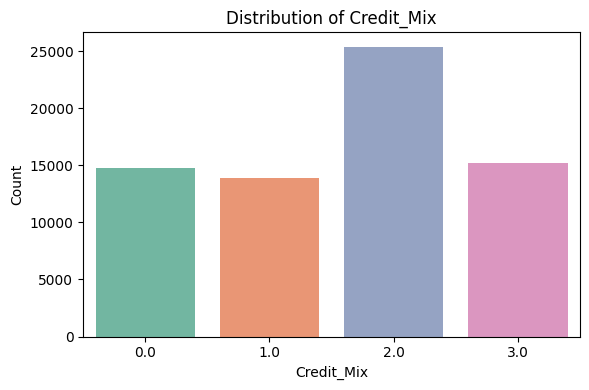

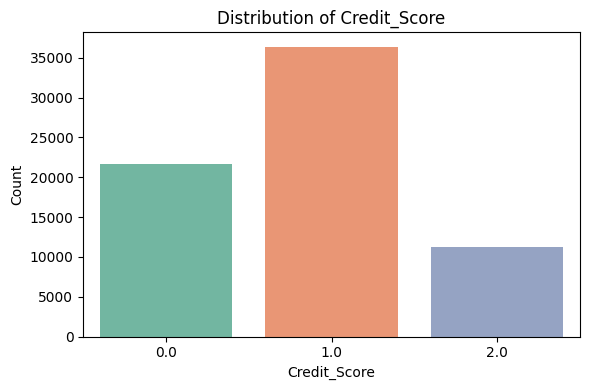

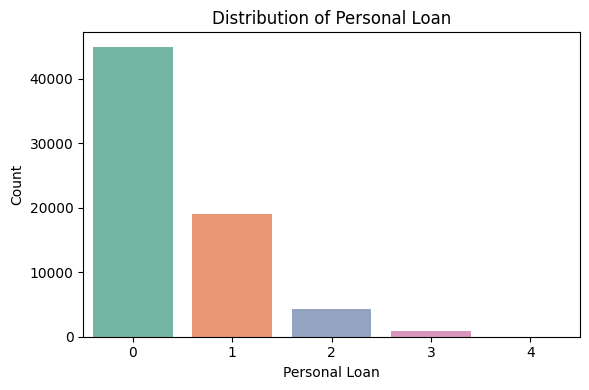

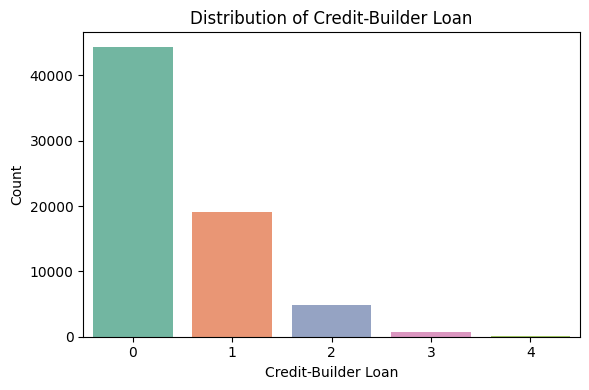

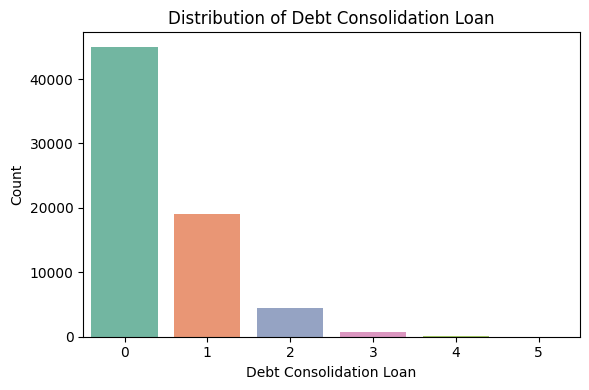

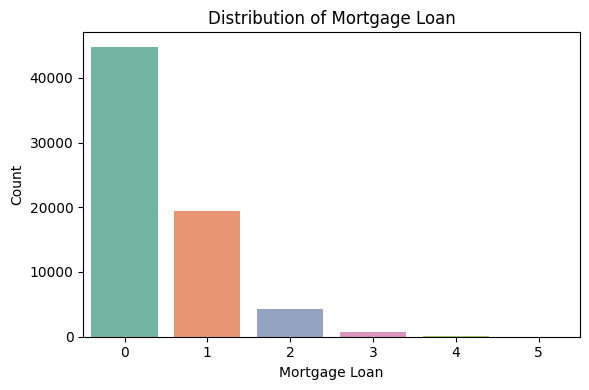

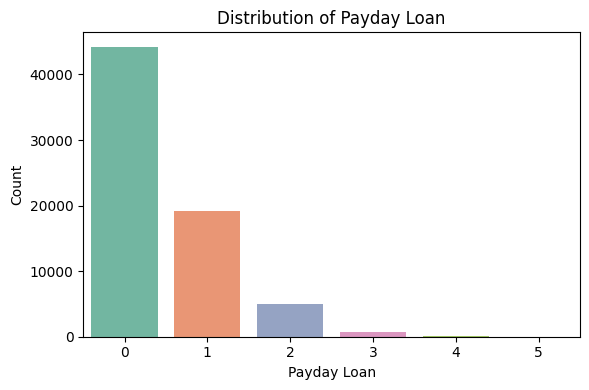

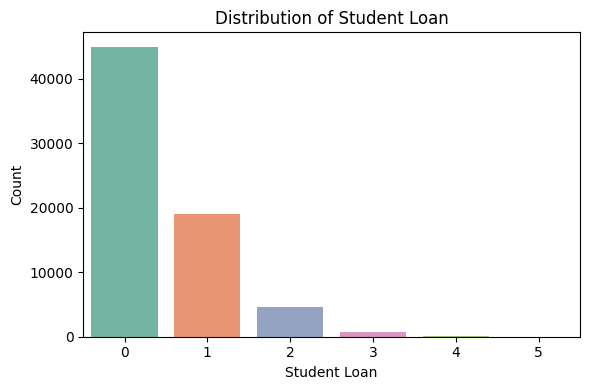

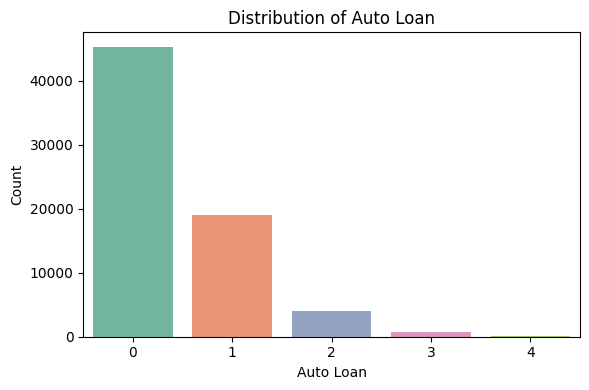

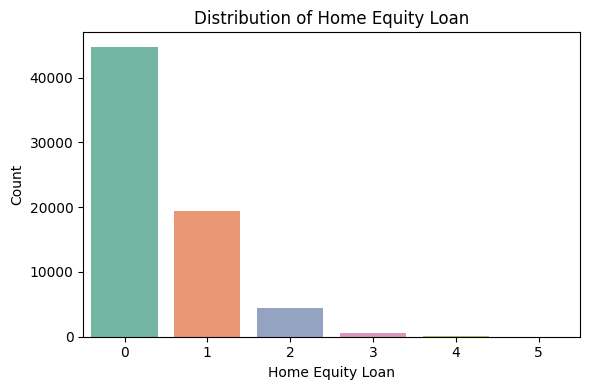

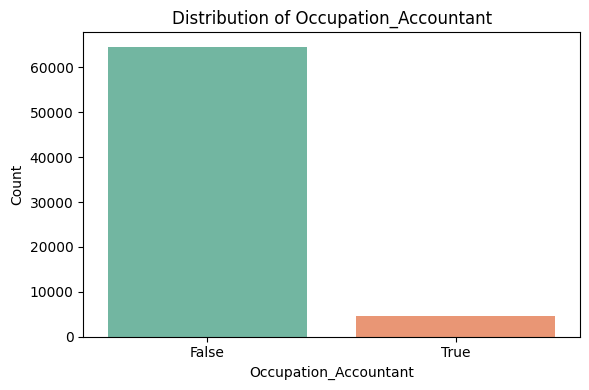

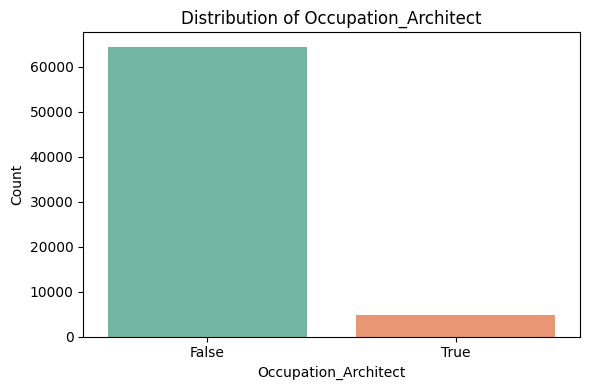

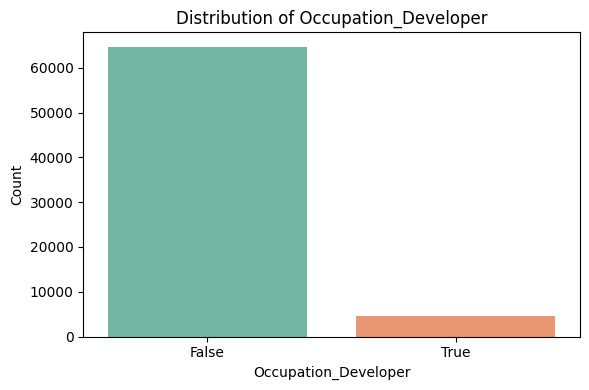

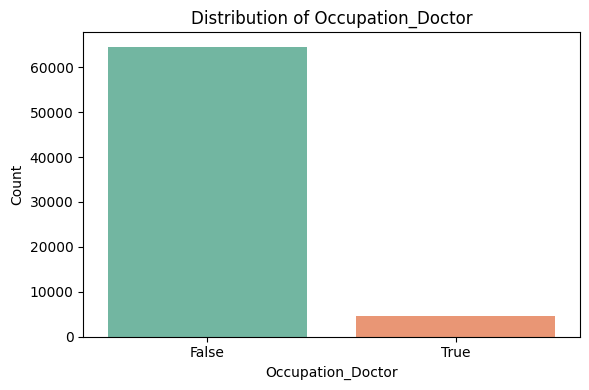

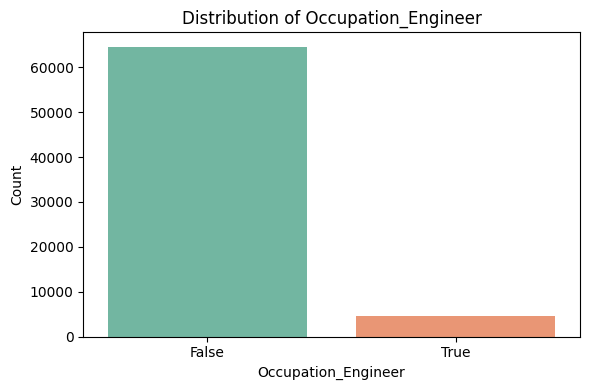

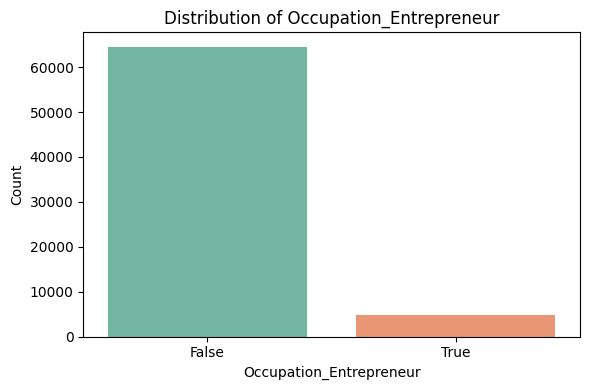

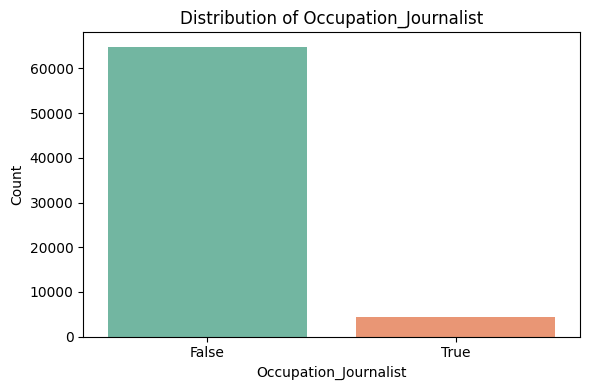

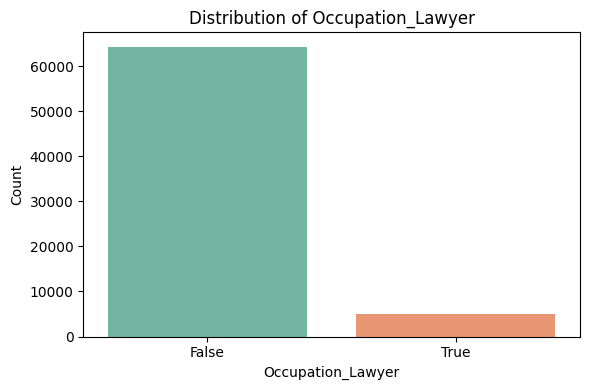

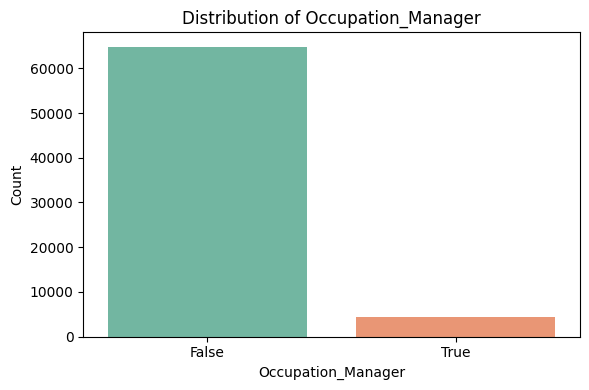

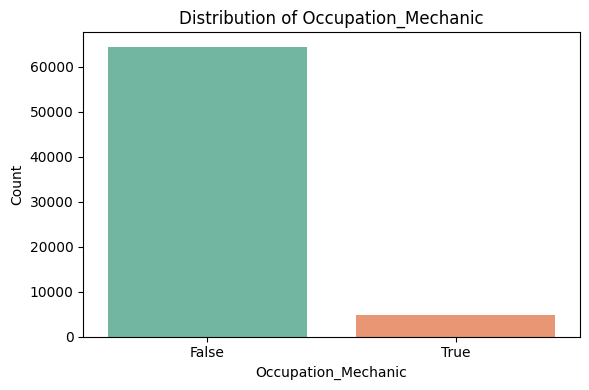

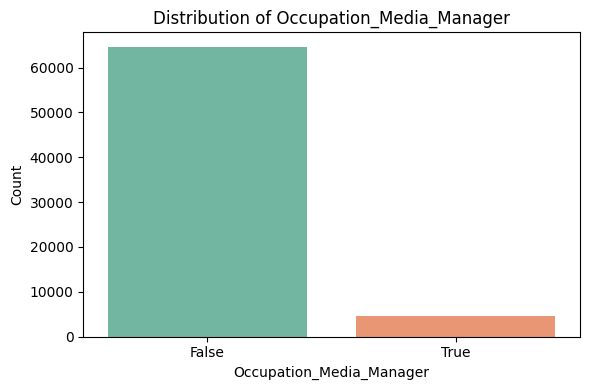

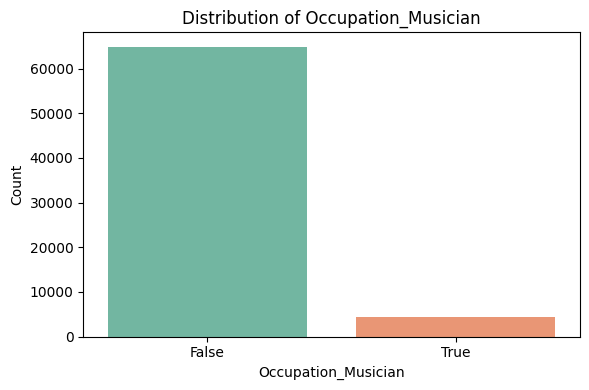

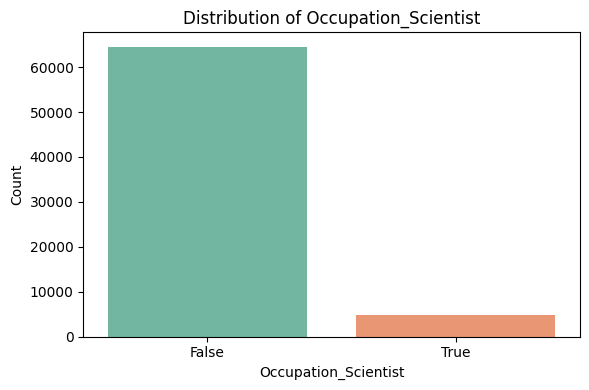

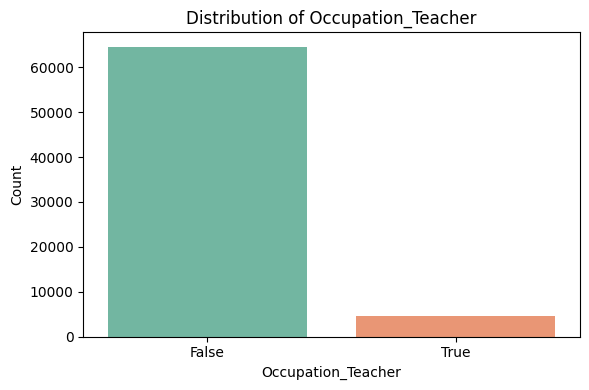

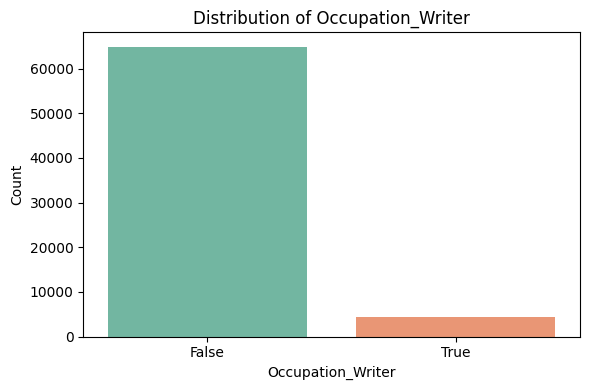

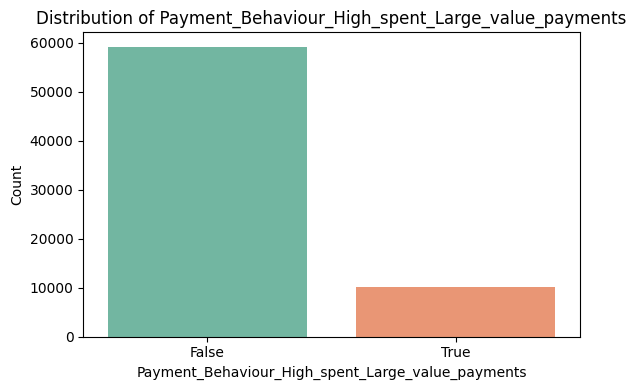

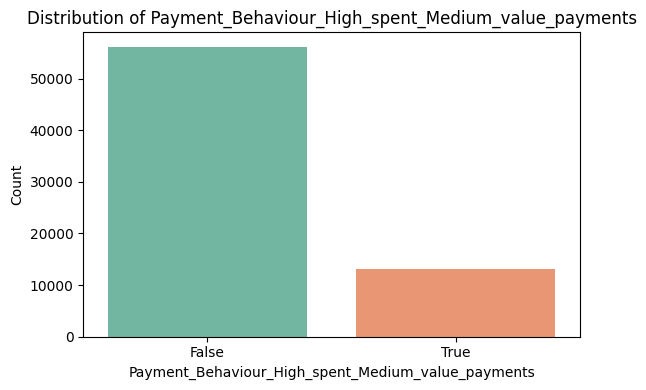

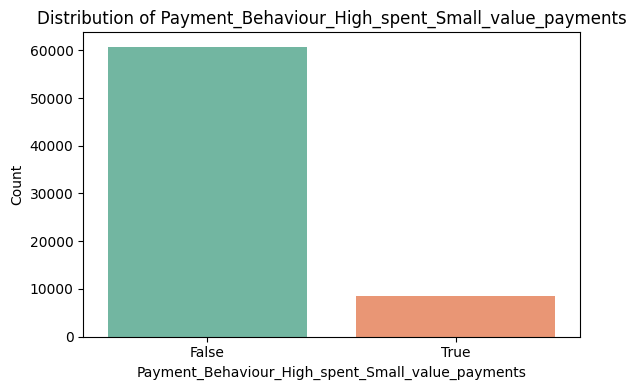

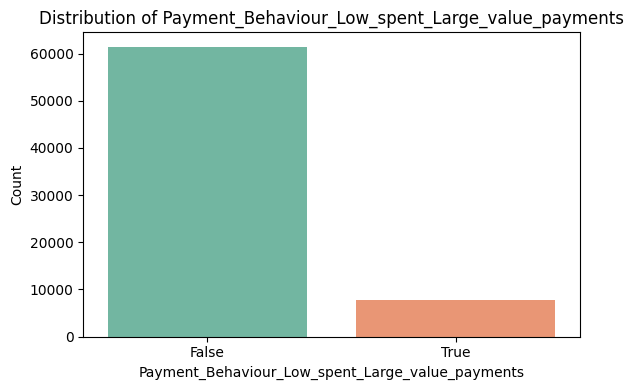

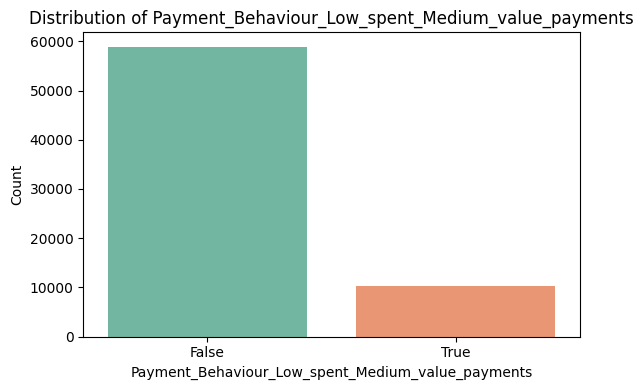

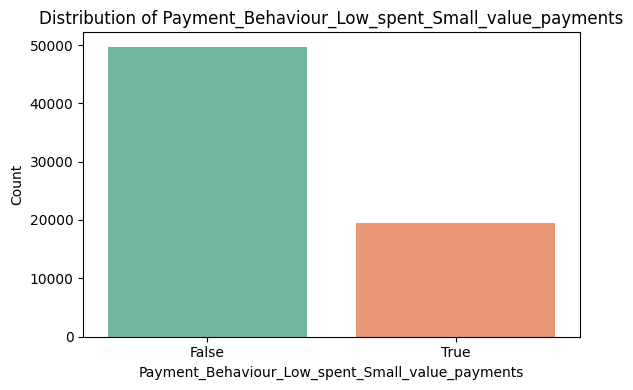

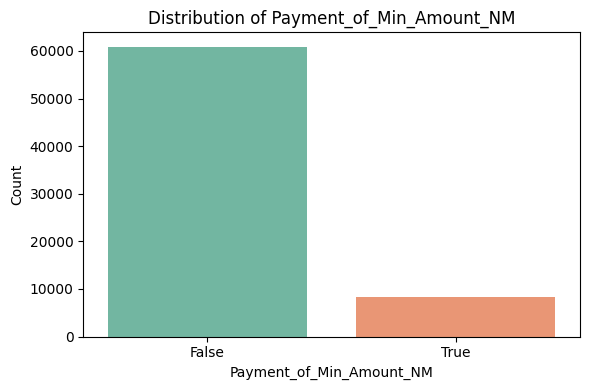

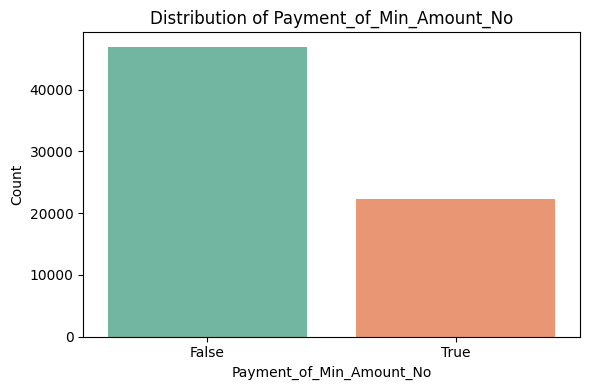

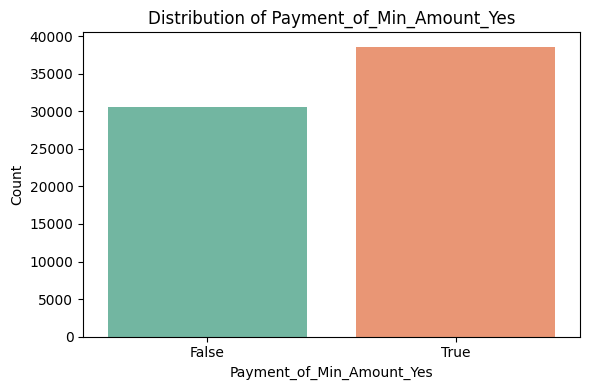

In [ ]:
non_numeric_cols = [col for col in df.columns if col not in numeric_df.columns]
non_numeric_df = df[non_numeric_cols]
for col in non_numeric_df.columns:
    plt.figure(figsize=(6,4))
    counts = non_numeric_df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, palette='Set2', hue = counts.index, legend =False )
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


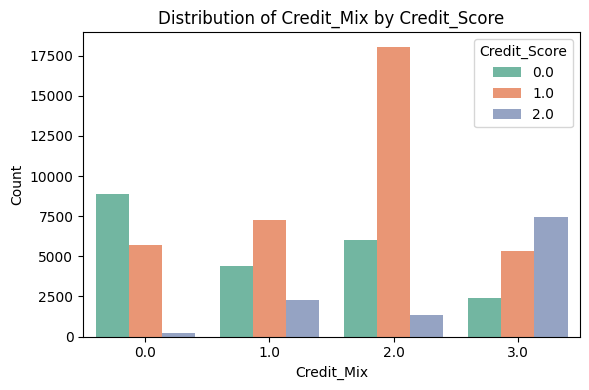

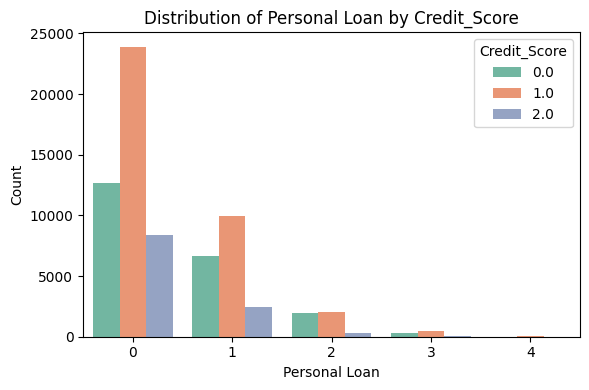

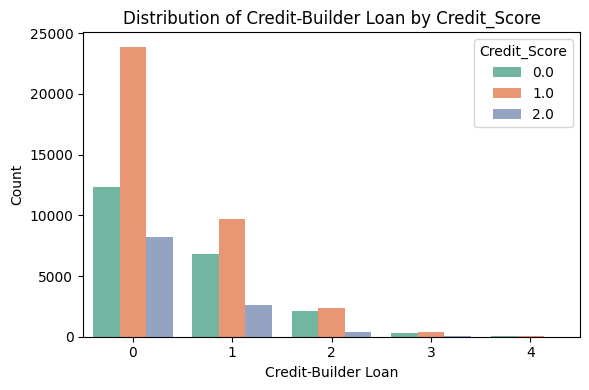

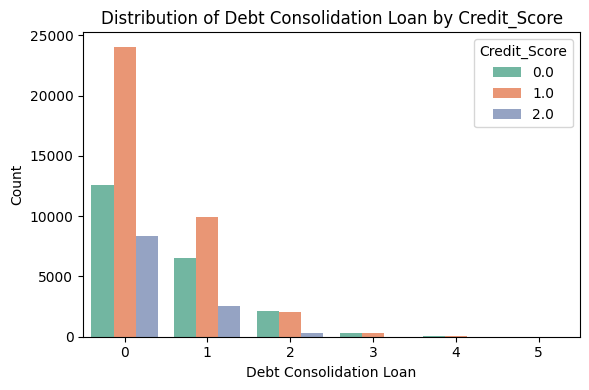

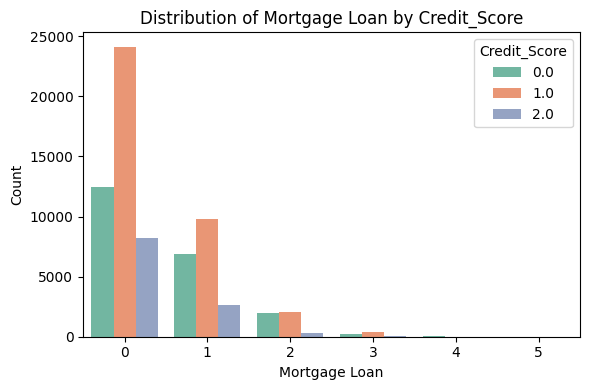

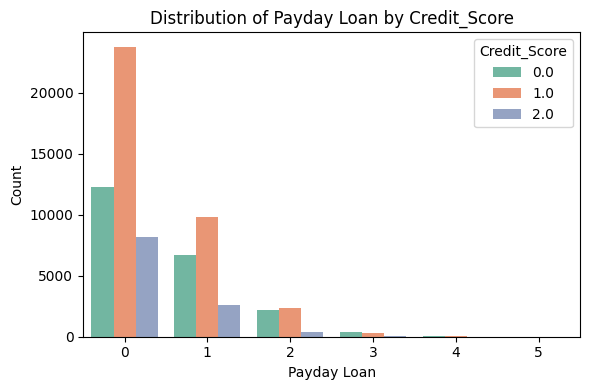

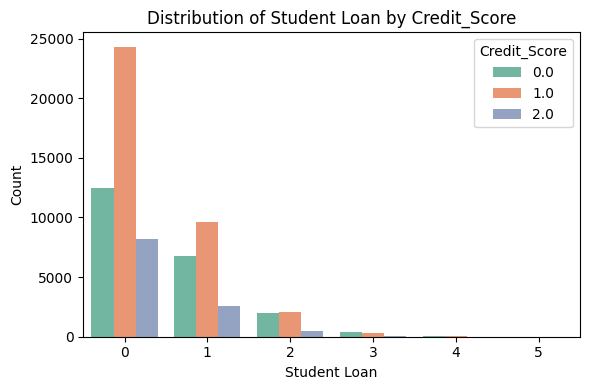

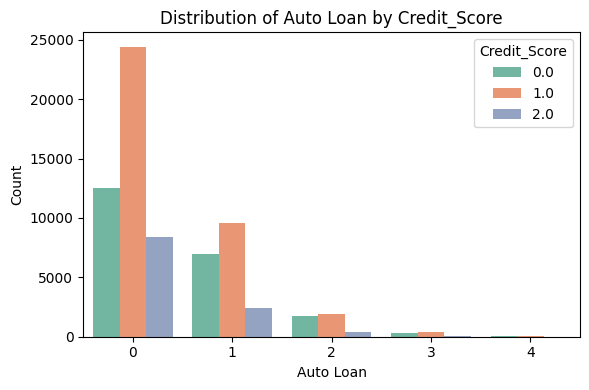

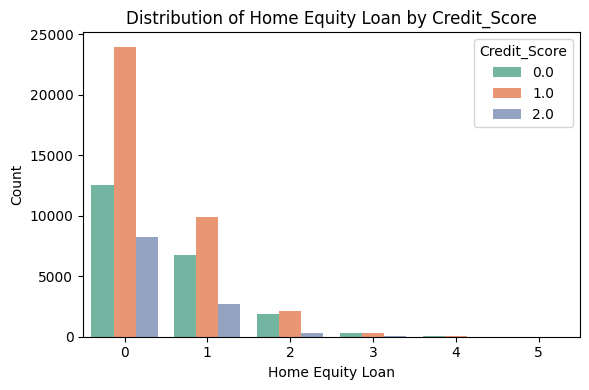

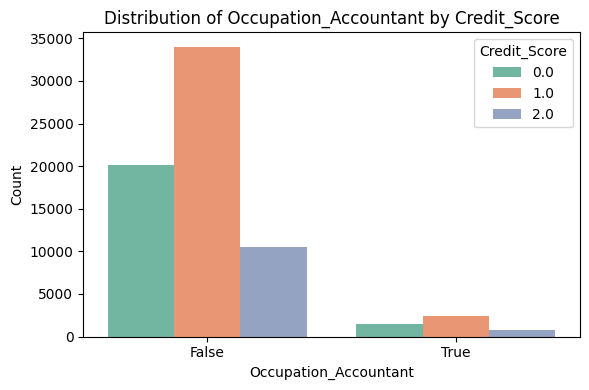

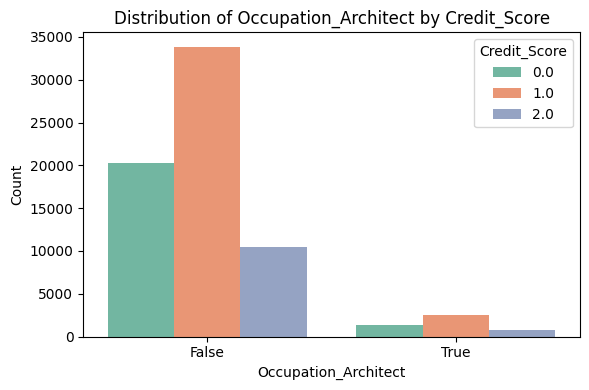

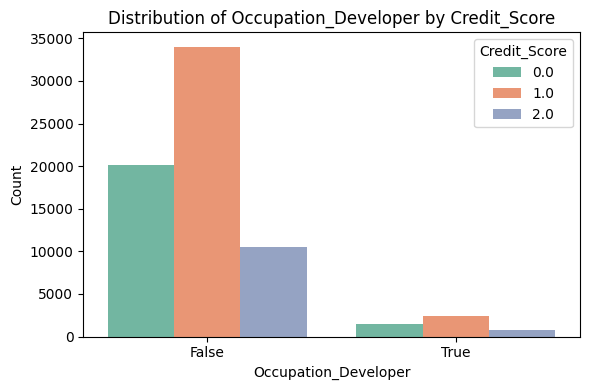

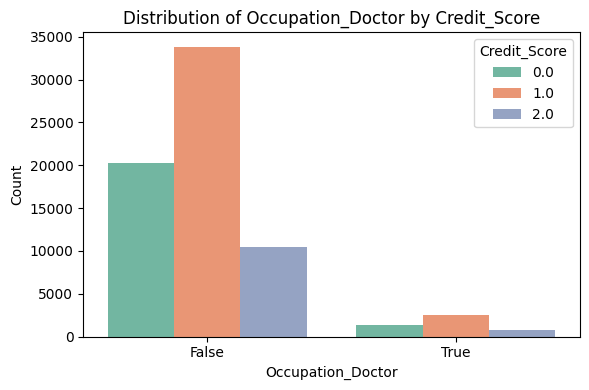

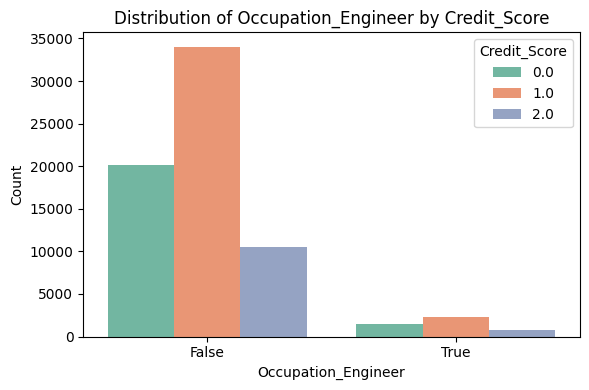

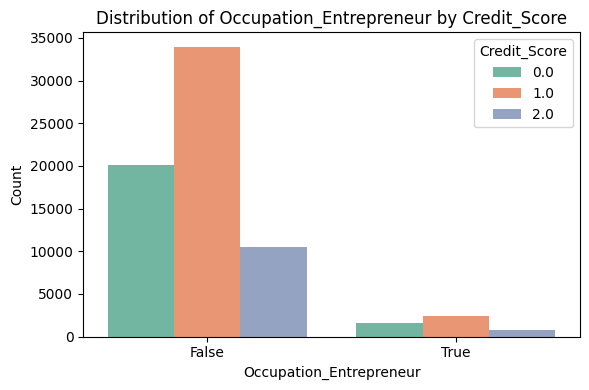

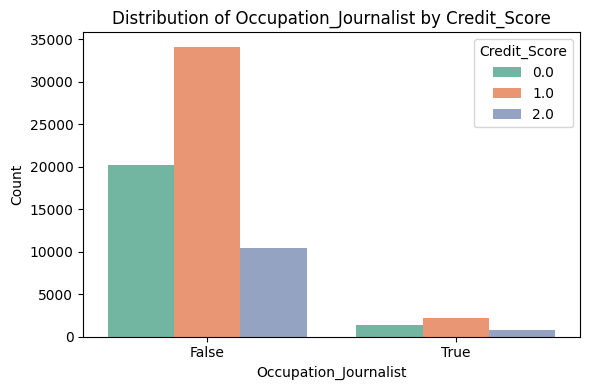

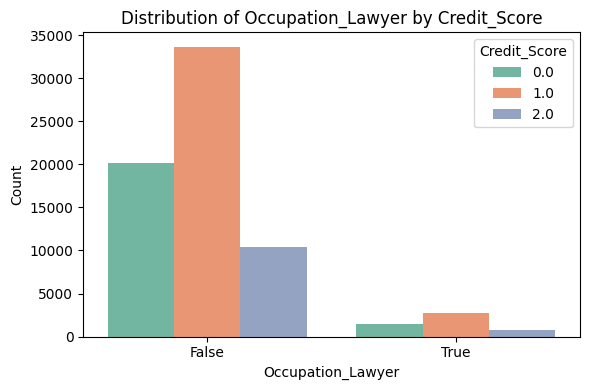

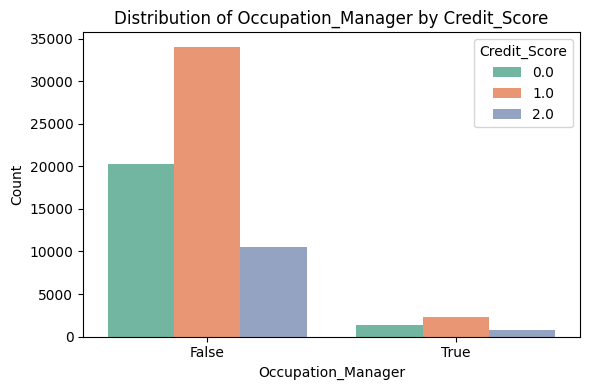

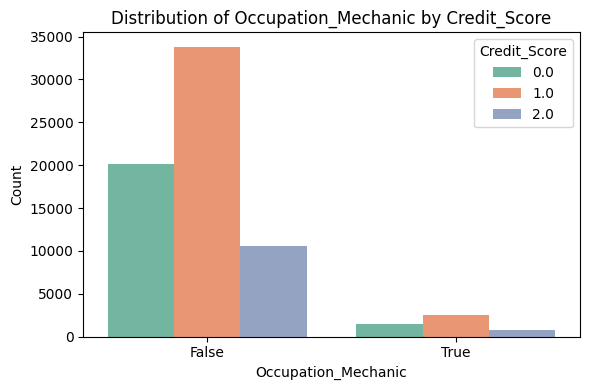

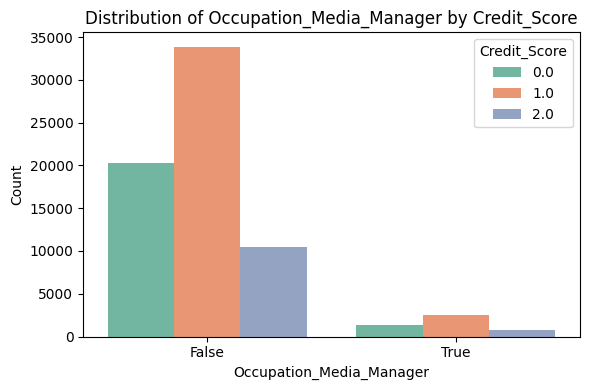

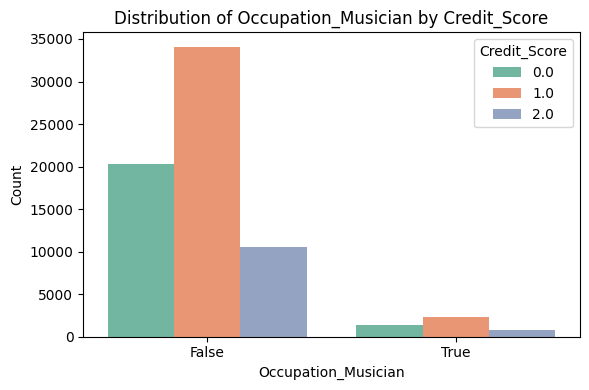

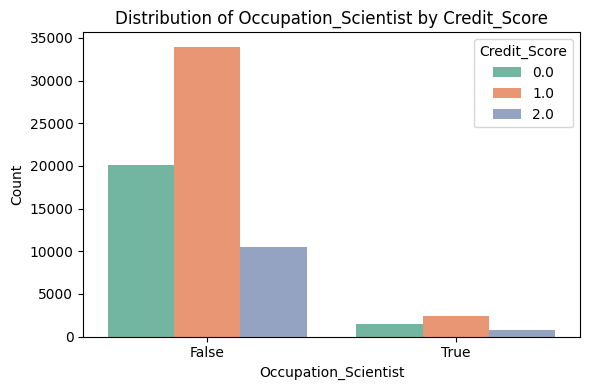

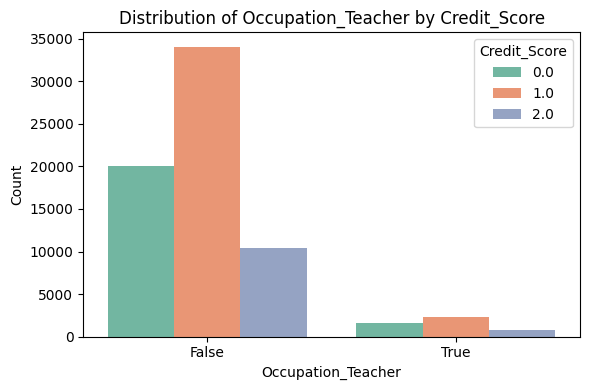

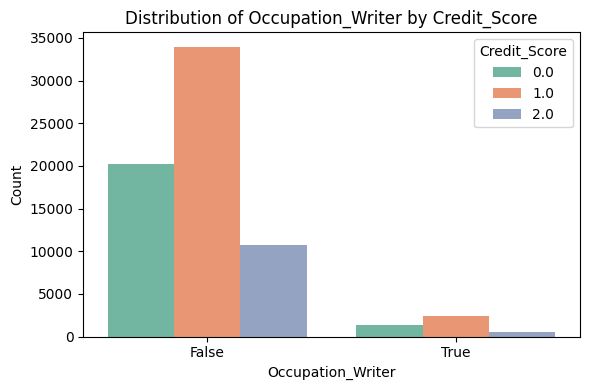

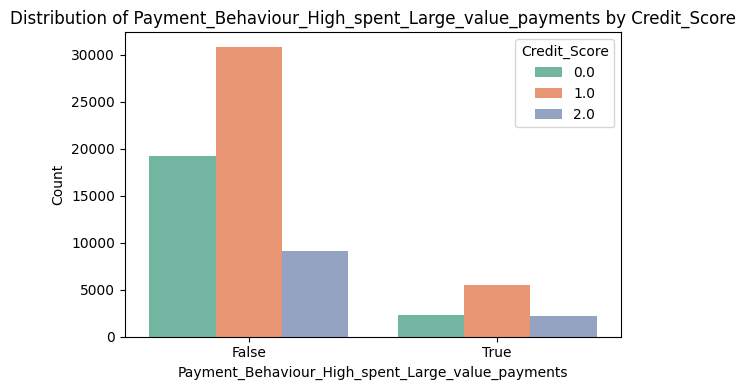

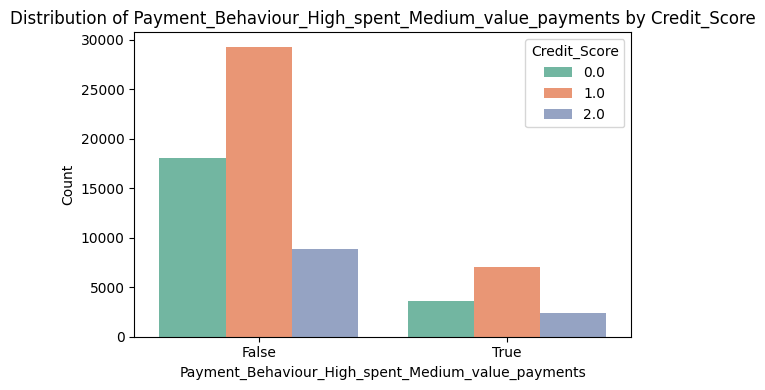

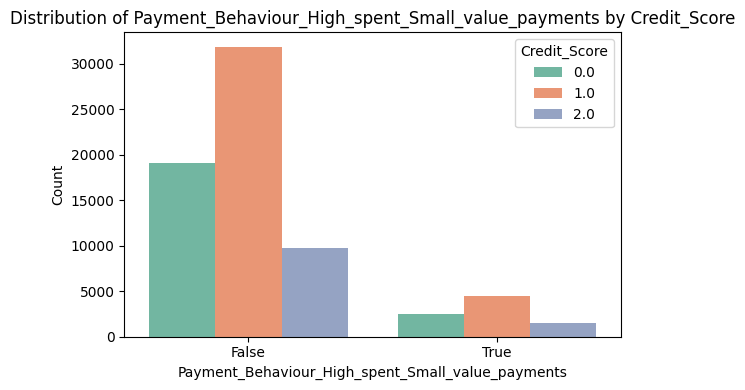

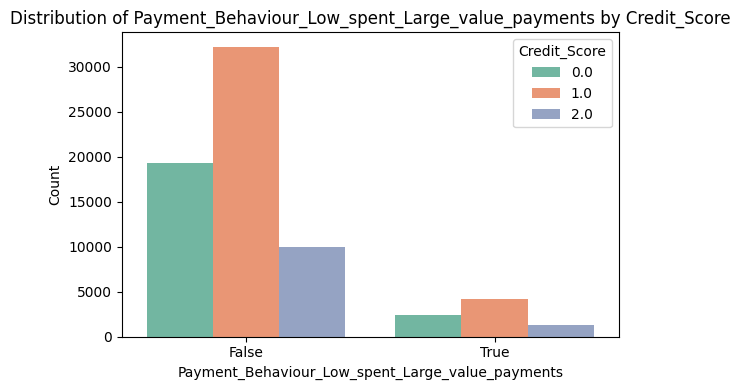

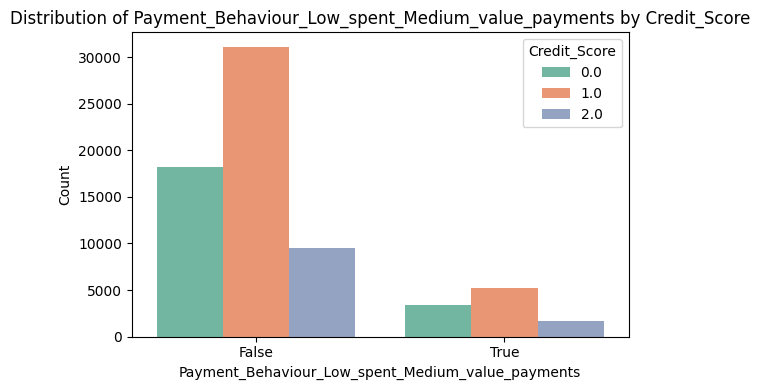

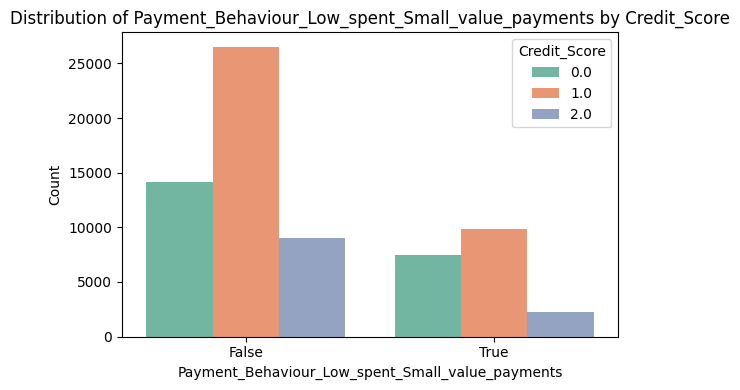

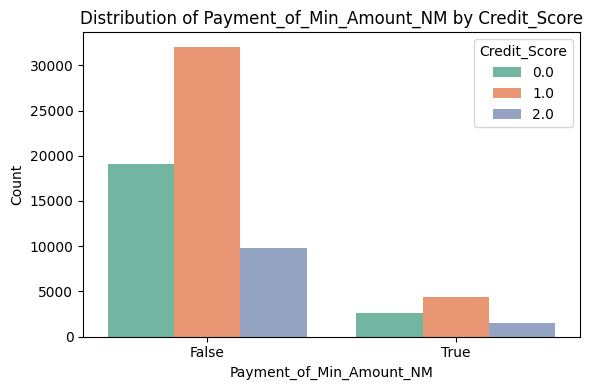

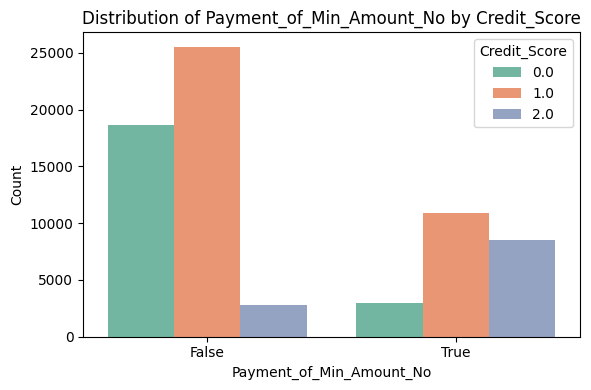

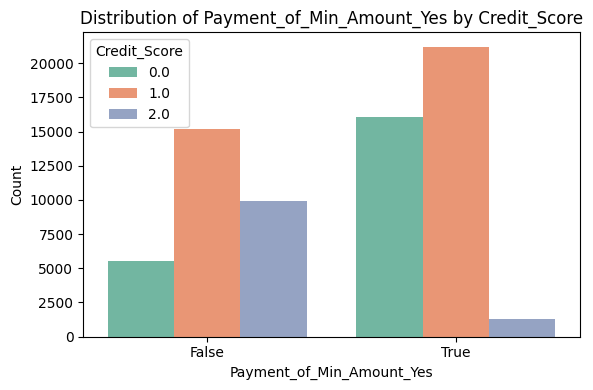

In [ ]:
for col in non_numeric_df.columns:
    if col == 'Credit_Score':
        continue

    plt.figure(figsize=(6,4))

    sns.countplot(x=col, hue='Credit_Score', data=df, palette='Set2')

    plt.title(f'Distribution of {col} by Credit_Score')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()
